In [75]:
import pandas as pd

rbps = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/mast_out/test_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python',header=None)
rbps.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']
rbps

,sequence_name,strand,id,alt_id,hit_start,hit_end,score,p_value
0,FBtr0085482_5utr,30,RNCMPT00097,LARK,1,7,-477.72,0.039600
1,FBtr0085482_5utr,6,RNCMPT00122,BRU-3,8,14,1131.57,0.000069
2,FBtr0085482_5utr,48,RNCMPT00058,RBP1,18,24,510.96,0.002950
3,FBtr0085482_5utr,48,RNCMPT00058,RBP1,28,34,1110.36,0.000051
4,FBtr0085482_5utr,8,RNCMPT00006,CG14718,39,46,328.73,0.005490
...,...,...,...,...,...,...,...,...
63437,FBtr0089173_3utr,50,RNCMPT00132,RBP9,384,390,776.36,0.001090
63438,FBtr0089173_3utr,66,RNCMPT00078,TRA2,393,399,832.52,0.000643
63439,FBtr0089173_3utr,9,RNCMPT00131,CG17838,402,408,764.20,0.001380
63440,FBtr0089173_3utr,13,RNCMPT00010,CG5213,411,418,403.53,0.004210


In [2]:
sg = rbps[rbps['alt_id'].isin(['ROX8','EIF-2ALPHA','PABP'])]
sg['tr_id'] = sg['sequence_name'].apply(lambda x: x.split('_')[0])
sg

/tmp/slurm.7402863/ipykernel_1975934/3512287124.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sg['tr_id'] = sg['sequence_name'].apply(lambda x: x.split('_')[0])


,sequence_name,strand,id,alt_id,hit_start,hit_end,score,p_value,tr_id
19,FBtr0085482_5utr,38,RNCMPT00139,PABP,176,182,937.27,0.000573,FBtr0085482
49,FBtr0085482_3utr,18,RNCMPT00273,EIF-2ALPHA,211,217,198.16,0.011600,FBtr0085482
55,FBtr0085482_3utr,54,RNCMPT00148,ROX8,259,265,275.11,0.013800,FBtr0085482
76,FBtr0085482_3utr,54,RNCMPT00148,ROX8,436,442,151.29,0.023600,FBtr0085482
79,FBtr0085482_3utr,54,RNCMPT00148,ROX8,462,468,970.85,0.000152,FBtr0085482
...,...,...,...,...,...,...,...,...,...
63396,FBtr0089173_3utr,54,RNCMPT00148,ROX8,9,15,275.11,0.013800,FBtr0089173
63408,FBtr0089173_3utr,54,RNCMPT00148,ROX8,119,125,870.62,0.000462,FBtr0089173
63414,FBtr0089173_3utr,38,RNCMPT00139,PABP,173,179,257.27,0.013100,FBtr0089173
63420,FBtr0089173_3utr,54,RNCMPT00148,ROX8,238,244,788.07,0.000791,FBtr0089173


In [3]:
utr_df = pd.crosstab(sg['sequence_name'], sg['alt_id'])

utr_df

alt_id,EIF-2ALPHA,PABP,ROX8
sequence_name,,,
FBtr0005088_3utr,0,1,1
FBtr0005088_5utr,1,2,0
FBtr0070027_3utr,1,3,2
FBtr0070027_5utr,1,1,0
FBtr0070103_5utr,1,1,1
...,...,...,...
FBtr0480509_5utr,1,6,3
FBtr0481643_3utr,1,4,6
FBtr0481643_5utr,0,0,1


In [4]:
from Bio import SeqIO
sequences = list(SeqIO.parse("/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/decay/test.fasta", "fasta"))
ids = [r.description.split()[1] for r in sequences]
TE = [r.id for r in sequences]
sequences_dict = {record.description.split()[1]:record.id for record in sequences}
sequences_dict_len = {record.description.split()[1]:len(record.seq) for record in sequences}
teDF = pd.DataFrame({'TE':TE}, index=ids)
teDF['TE'] = teDF['TE'].astype(float)
teDF.sort_values(by='TE', ascending=False, inplace=True)
teDF

,TE
FBtr0081915,1.970555
FBtr0344371,1.843867
FBtr0079403,1.475822
FBtr0082764,1.417045
FBtr0077764,1.346379
...,...
FBtr0075312,0.067529
FBtr0088469,0.066258
FBtr0082338,0.060430
FBtr0070027,0.054332


In [5]:
preds = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/dvclive/codonOnlyClassificationMLP/codonOnly_final/test_predictions_vs_true_labels.csv')
preds.sort_values(by='True Labels', ascending=False, inplace=True)
preds.index = teDF.index
preds['diff'] = preds['Predictions'] - preds['True Labels']
preds

,True Labels,Predictions,diff
FBtr0081915,1.970555,0.921382,-1.049173
FBtr0344371,1.843867,0.560217,-1.283650
FBtr0079403,1.475822,1.701466,0.225644
FBtr0082764,1.417045,0.568157,-0.848889
FBtr0077764,1.346379,0.498631,-0.847748
...,...,...,...
FBtr0075312,0.067529,0.517033,0.449503
FBtr0088469,0.066258,0.431023,0.364765
FBtr0082338,0.060430,0.439648,0.379218
FBtr0070027,0.054332,0.402155,0.347823


In [6]:
import numpy as np
fullpreds = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/predict/predictions_vs_true_labels.csv')
fullpreds.sort_values(by='True Labels', ascending=False, inplace=True)
tr_ids = []
i = 0  # index for fullpreds
for id in teDF.index:
    if i >= len(fullpreds):
        break
    te_val = np.round(teDF.loc[id, 'TE'].astype(float), 4)
    pred_val = np.round(fullpreds.iloc[i]['True Labels'], 4)
    if te_val == pred_val:
        tr_ids.append(id)
        i += 1
fullpreds.index = tr_ids
fullpreds['diff'] = fullpreds['Predictions'] - fullpreds['True Labels']
fullpreds
#fullpreds.index = teDF.index
#fullpreds['diff'] = fullpreds['Predictions'] - fullpreds['True Labels']
fullpreds

,True Labels,Predictions,diff
FBtr0081915,1.970555,0.766872,-1.203683
FBtr0344371,1.843867,0.392644,-1.451223
FBtr0079403,1.475822,1.440579,-0.035243
FBtr0082764,1.417045,0.668212,-0.748834
FBtr0077764,1.346379,0.608664,-0.737715
...,...,...,...
FBtr0075312,0.067529,0.434604,0.367075
FBtr0088469,0.066258,0.374190,0.307932
FBtr0082338,0.060430,0.470750,0.410320
FBtr0070027,0.054332,0.397704,0.343372


In [7]:
predMerged = pd.merge(preds, fullpreds, left_index=True, right_index=True, suffixes=('_mlp', '_full'))
predMerged['predDiff'] = predMerged['Predictions_mlp'] - predMerged['Predictions_full']
predMerged

,True Labels_mlp,Predictions_mlp,diff_mlp,True Labels_full,Predictions_full,diff_full,predDiff
FBtr0081915,1.970555,0.921382,-1.049173,1.970555,0.766872,-1.203683,0.154510
FBtr0344371,1.843867,0.560217,-1.283650,1.843867,0.392644,-1.451223,0.167574
FBtr0079403,1.475822,1.701466,0.225644,1.475822,1.440579,-0.035243,0.260887
FBtr0082764,1.417045,0.568157,-0.848889,1.417045,0.668212,-0.748834,-0.100055
FBtr0077764,1.346379,0.498631,-0.847748,1.346379,0.608664,-0.737715,-0.110032
...,...,...,...,...,...,...,...
FBtr0075312,0.067529,0.517033,0.449503,0.067529,0.434604,0.367075,0.082428
FBtr0088469,0.066258,0.431023,0.364765,0.066258,0.374190,0.307932,0.056833
FBtr0082338,0.060430,0.439648,0.379218,0.060430,0.470750,0.410320,-0.031102
FBtr0070027,0.054332,0.402155,0.347823,0.054332,0.397704,0.343372,0.004451


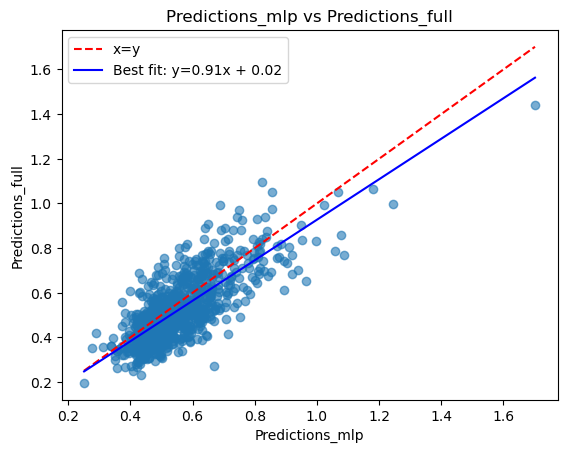

In [8]:
import numpy as np

import matplotlib.pyplot as plt

# Scatter plot of Predictions_mlp vs Predictions_full
plt.scatter(predMerged['Predictions_mlp'], predMerged['Predictions_full'], alpha=0.6)
plt.xlabel('Predictions_mlp')
plt.ylabel('Predictions_full')
plt.title('Predictions_mlp vs Predictions_full')

# Add x=y line in red
x_min = predMerged['Predictions_mlp'].min()
x_max = predMerged['Predictions_mlp'].max()
plt.plot([x_min, x_max], [x_min, x_max], color='red', linestyle='--', label='x=y')

# Add line of best fit in blue
#slope, intercept = np.polyfit(predMerged['Predictions_mlp'], predMerged['Predictions_full'], 1)
slope, intercept = np.polyfit(predMerged['Predictions_mlp'][predMerged['Predictions_mlp'] < 1], predMerged['Predictions_full'][predMerged['Predictions_mlp'] < 1], 1)
x_vals = np.linspace(x_min, x_max, 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='blue', label=f'Best fit: y={slope:.2f}x + {intercept:.2f}')

plt.legend()
plt.show()

In [9]:
predMerged['above_line'] = predMerged['Predictions_full'] > (slope * predMerged['Predictions_mlp'] + intercept)
predMerged

,True Labels_mlp,Predictions_mlp,diff_mlp,True Labels_full,Predictions_full,diff_full,predDiff,above_line
FBtr0081915,1.970555,0.921382,-1.049173,1.970555,0.766872,-1.203683,0.154510,False
FBtr0344371,1.843867,0.560217,-1.283650,1.843867,0.392644,-1.451223,0.167574,False
FBtr0079403,1.475822,1.701466,0.225644,1.475822,1.440579,-0.035243,0.260887,False
FBtr0082764,1.417045,0.568157,-0.848889,1.417045,0.668212,-0.748834,-0.100055,True
FBtr0077764,1.346379,0.498631,-0.847748,1.346379,0.608664,-0.737715,-0.110032,True
...,...,...,...,...,...,...,...,...
FBtr0075312,0.067529,0.517033,0.449503,0.067529,0.434604,0.367075,0.082428,False
FBtr0088469,0.066258,0.431023,0.364765,0.066258,0.374190,0.307932,0.056833,False
FBtr0082338,0.060430,0.439648,0.379218,0.060430,0.470750,0.410320,-0.031102,True
FBtr0070027,0.054332,0.402155,0.347823,0.054332,0.397704,0.343372,0.004451,True


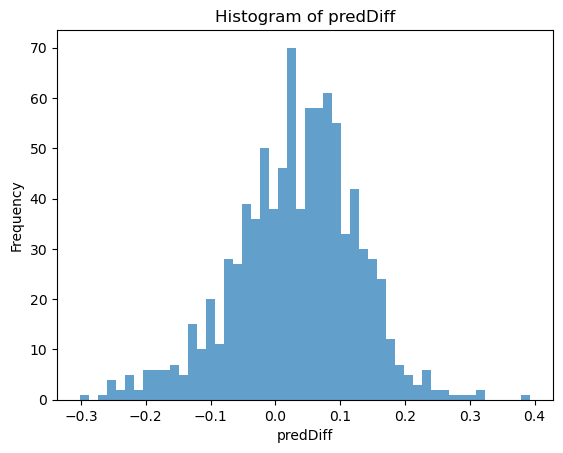

In [10]:
predMerged['predDiff'].plot.hist(bins=50, alpha=0.7)
plt.xlabel('predDiff')
plt.ylabel('Frequency')
plt.title('Histogram of predDiff')
plt.show()

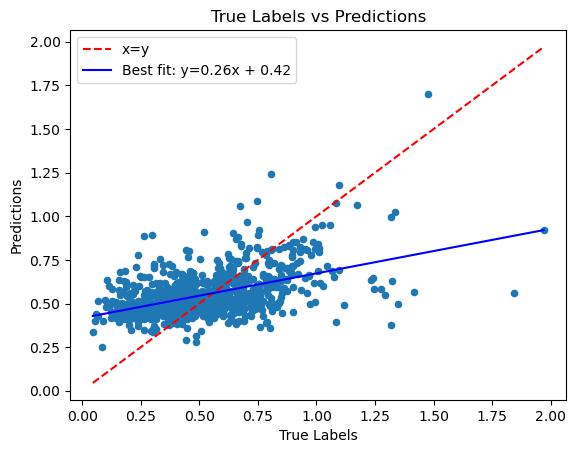

In [11]:
import numpy as np

import matplotlib.pyplot as plt

# Scatter plot of True Labels vs Predictions
preds.plot.scatter(x='True Labels', y='Predictions')
plt.xlabel('True Labels')
plt.ylabel('Predictions')
plt.title('True Labels vs Predictions')

# Add x=y line in red
x_min = preds['True Labels'].min()
x_max = preds['True Labels'].max()
plt.plot([x_min, x_max], [x_min, x_max], color='red', linestyle='--', label='x=y')

# Add line of best fit in blue
slope, intercept = np.polyfit(preds['True Labels'], preds['Predictions'], 1)
x_vals = np.linspace(x_min, x_max, 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='blue', label=f'Best fit: y={slope:.2f}x + {intercept:.2f}')

plt.legend()
plt.show()

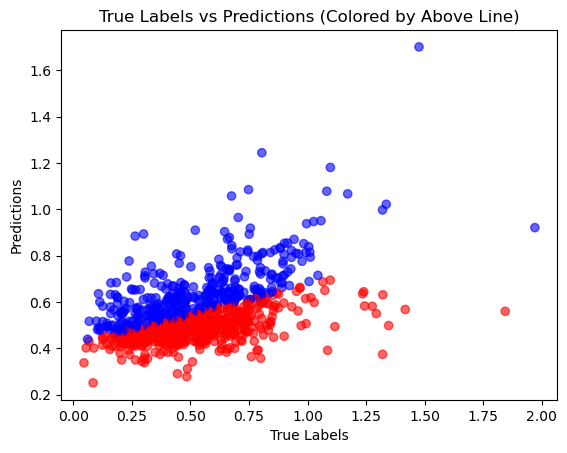

In [12]:
# Calculate the line of best fit using True Labels as x and Predictions as y
slope, intercept = np.polyfit(preds['True Labels'], preds['Predictions'], 1)

# Add a new column 'above_line' that is True if Predictions > line, False otherwise
preds['above_line'] = preds['Predictions'] > (slope * preds['True Labels'] + intercept)

# Plot scatter plot colored by 'above_line'
colors = preds['above_line'].map({True: 'blue', False: 'red'})
plt.scatter(preds['True Labels'], preds['Predictions'], c=colors, alpha=0.6)
plt.xlabel('True Labels')
plt.ylabel('Predictions')
plt.title('True Labels vs Predictions (Colored by Above Line)')
plt.show()

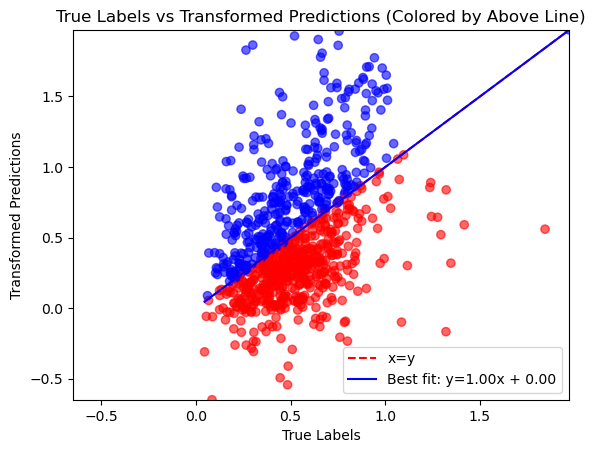

In [13]:
# Calculate the line of best fit using True Labels as x and Predictions as y
# Calculate the line of best fit using True Labels as x and Predictions as y
slope, intercept = np.polyfit(preds['True Labels'], preds['Predictions'], 1)

# Transform predictions to make the line of best fit match y=x
preds_copy = preds.copy()
preds_copy['Predictions'] = (preds_copy['Predictions'] - intercept) / slope

# Recalculate slope and intercept on transformed data (should be 1 and 0)
slope, intercept = np.polyfit(preds_copy['True Labels'], preds_copy['Predictions'], 1)

# Add a new column 'above_line' that is True if Predictions > line, False otherwise
preds_copy['above_line'] = preds_copy['Predictions'] > (slope * preds_copy['True Labels'] + intercept)

# Plot scatter plot colored by 'above_line'
colors = preds_copy['above_line'].map({True: 'blue', False: 'red'})
plt.scatter(preds_copy['True Labels'], preds_copy['Predictions'], c=colors, alpha=0.6)
plt.xlabel('True Labels')
plt.ylabel('Transformed Predictions')
plt.title('True Labels vs Transformed Predictions (Colored by Above Line)')

# Add x=y line in red
x_min = preds_copy['True Labels'].min()
x_max = preds_copy['True Labels'].max()
plt.plot([x_min, x_max], [x_min, x_max], color='red', linestyle='--', label='x=y')

# Add line of best fit in blue (should now be x=y)
x_vals = np.linspace(x_min, x_max, 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='blue', label=f'Best fit: y={slope:.2f}x + {intercept:.2f}')

# Make x and y ranges the same
overall_min = preds_copy['Predictions'].min()
overall_max = preds_copy['True Labels'].max()
plt.xlim(overall_min, overall_max)
plt.ylim(overall_min, overall_max)

plt.legend()
plt.show()

In [14]:
preds


,True Labels,Predictions,diff,above_line
FBtr0081915,1.970555,0.921382,-1.049173,True
FBtr0344371,1.843867,0.560217,-1.283650,False
FBtr0079403,1.475822,1.701466,0.225644,True
FBtr0082764,1.417045,0.568157,-0.848889,False
FBtr0077764,1.346379,0.498631,-0.847748,False
...,...,...,...,...
FBtr0075312,0.067529,0.517033,0.449503,True
FBtr0088469,0.066258,0.431023,0.364765,False
FBtr0082338,0.060430,0.439648,0.379218,True
FBtr0070027,0.054332,0.402155,0.347823,False


In [15]:
tr_df = pd.crosstab(sg['tr_id'], sg['alt_id'])
tr_df['sum'] = tr_df.sum(axis=1)
tr_df['normalized'] = [tr_df['sum'][id]/sequences_dict_len.get(id, 1) for id in tr_df.index]
tr_df['TE'] = [sequences_dict.get(tr_id, None) for tr_id in tr_df.index]
tr_df['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in tr_df.index]
tr_df

alt_id,EIF-2ALPHA,PABP,ROX8,sum,normalized,TE,above_line
tr_id,,,,,,,
FBtr0005088,1,3,1,5,0.007862,0.420581986038326,False
FBtr0070027,2,4,2,8,0.012140,0.054332255622241914,False
FBtr0070103,1,1,1,3,0.005245,0.3349421374723737,False
FBtr0070110,1,3,1,5,0.005800,0.6684791022728098,False
FBtr0070122,1,3,0,4,0.010811,0.48311570222970557,False
...,...,...,...,...,...,...,...
FBtr0479909,1,9,3,13,0.009306,0.5748571365593609,False
FBtr0479916,1,1,5,7,0.007202,0.251355790221334,True
FBtr0480509,6,9,10,25,0.011241,0.5243008801619682,False


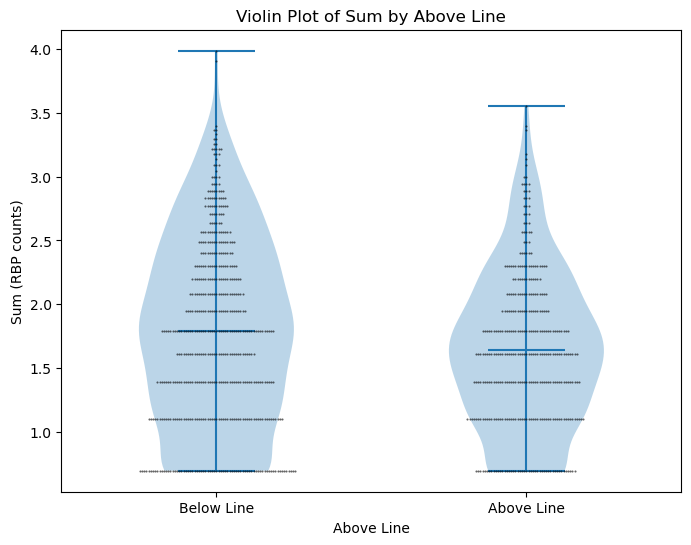

In [16]:
import seaborn as sns

import matplotlib.pyplot as plt

# Group the 'sum' values by 'above_line'
above = np.log(1+tr_df[tr_df['above_line'] == True]['sum'])
below = np.log(1+tr_df[tr_df['above_line'] == False]['sum'])

# Create violin plot
plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('Sum (RBP counts)')
plt.title('Violin Plot of Sum by Above Line')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

plt.show()

In [17]:
from scipy.stats import ttest_ind

# Assuming tr_df is available from previous cells
below = np.log(1 + tr_df[tr_df['above_line'] == False]['sum'])
above = np.log(1 + tr_df[tr_df['above_line'] == True]['sum'])

# Perform one-tailed t-test to check if below > above
t_stat, p_value = ttest_ind(below, above, alternative='greater')

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 2.950646750994779
P-value: 0.001629611385984455


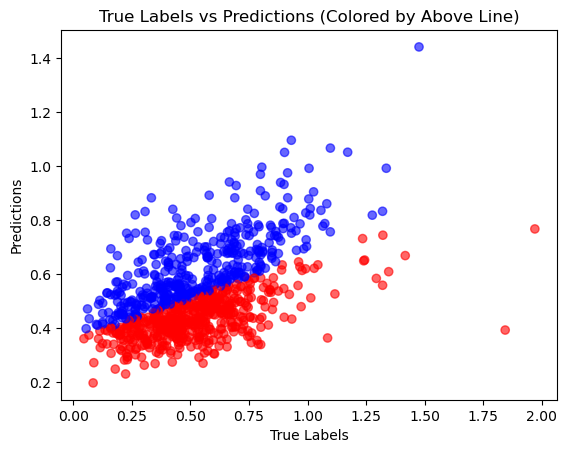

In [18]:
# Calculate the line of best fit using True Labels as x and Predictions as y
slope, intercept = np.polyfit(fullpreds['True Labels'], fullpreds['Predictions'], 1)

# Add a new column 'above_line' that is True if Predictions > line, False otherwise
fullpreds['above_line'] = fullpreds['Predictions'] > (slope * fullpreds['True Labels'] + intercept)

# Plot scatter plot colored by 'above_line'
colors = fullpreds['above_line'].map({True: 'blue', False: 'red'})
plt.scatter(fullpreds['True Labels'], fullpreds['Predictions'], c=colors, alpha=0.6)
plt.xlabel('True Labels')
plt.ylabel('Predictions')
plt.title('True Labels vs Predictions (Colored by Above Line)')
plt.show()

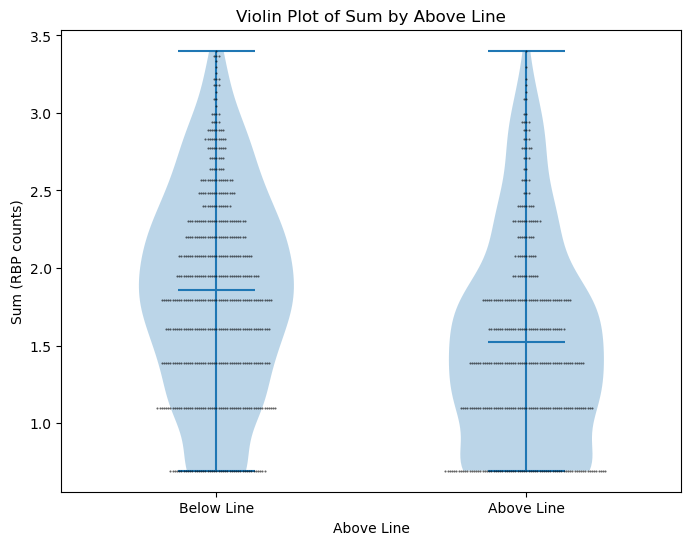

In [19]:
tr_df['above_line_full'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in tr_df.index]
import seaborn as sns

import matplotlib.pyplot as plt

# Group the 'sum' values by 'above_line'
above = np.log(1+tr_df[tr_df['above_line_full'] == True]['sum'])
below = np.log(1+tr_df[tr_df['above_line_full'] == False]['sum'])

# Create violin plot
plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('Sum (RBP counts)')
plt.title('Violin Plot of Sum by Above Line')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

plt.show()

In [20]:
from scipy.stats import ttest_ind

# Assuming tr_df is available from previous cells
below = np.log(1 + tr_df[tr_df['above_line_full'] == False]['sum'])
above = np.log(1 + tr_df[tr_df['above_line_full'] == True]['sum'])

# Perform one-tailed t-test to check if below > above
t_stat, p_value = ttest_ind(below, above, alternative='greater')

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 7.163298277180989
P-value: 8.650915617585875e-13


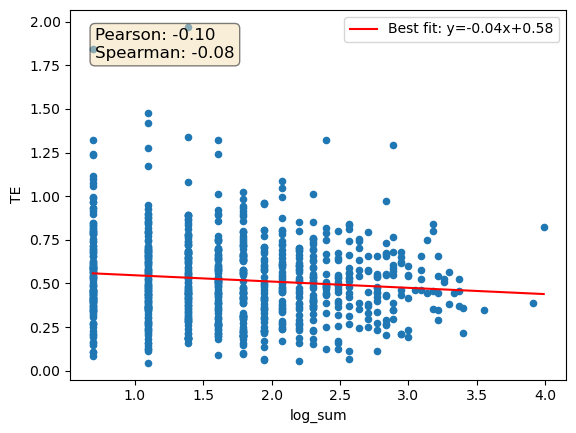

In [21]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

tr_df['log_sum'] = np.log(tr_df['sum'] + 1)  # Adding 1 to avoid log(0)
tr_df['TE'] = tr_df['TE'].astype(float)

# Calculate correlations
pearson_corr, _ = pearsonr(tr_df['log_sum'], tr_df['TE'])
spearman_corr, _ = spearmanr(tr_df['log_sum'], tr_df['TE'])

# Fit line of best fit
slope, intercept = np.polyfit(tr_df['log_sum'], tr_df['TE'], 1)
line_x = np.linspace(tr_df['log_sum'].min(), tr_df['log_sum'].max(), 100)
line_y = slope * line_x + intercept

# Plot scatter plot
ax = tr_df.plot.scatter(x='log_sum', y='TE')

# Add line of best fit
ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend()
plt.show()

/tmp/slurm.7402863/ipykernel_1975934/2508314785.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped.values, labels=grouped.index)


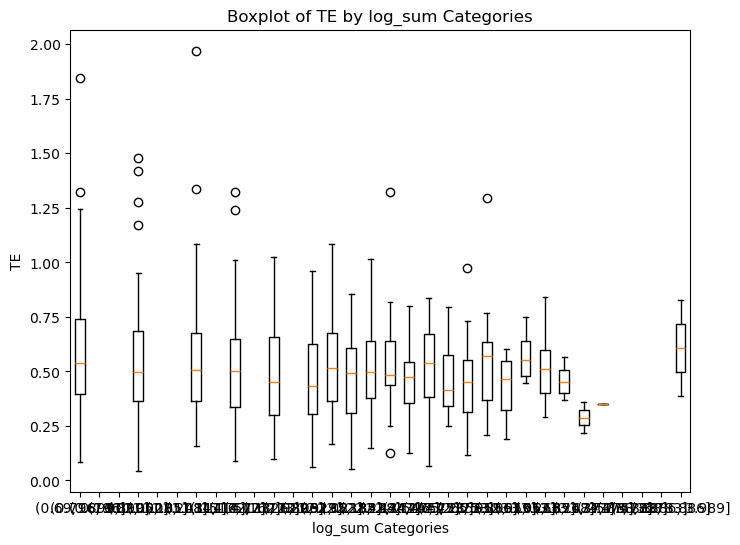

In [22]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

tr_df['log_sum'] = np.log(tr_df['sum'] + 1)  # Adding 1 to avoid log(0)
tr_df['TE'] = tr_df['TE'].astype(float)

# Bin log_sum into categories (e.g., quartiles)
tr_df['log_sum_bins'] = pd.cut(tr_df['log_sum'], bins=len(tr_df['log_sum'].unique()))#, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Group TE by bins
grouped = tr_df.groupby('log_sum_bins')['TE'].apply(list)

# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(grouped.values, labels=grouped.index)
plt.xlabel('log_sum Categories')
plt.ylabel('TE')
plt.title('Boxplot of TE by log_sum Categories')
plt.show()


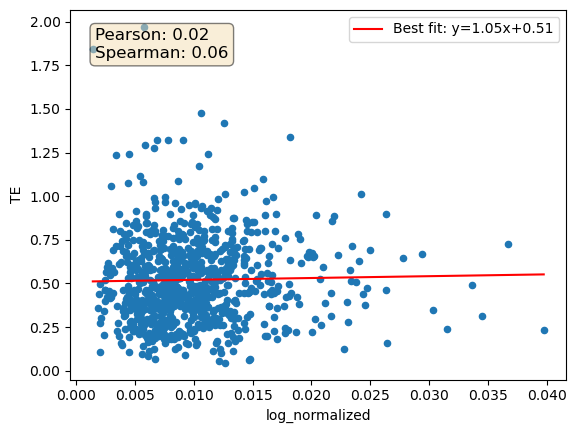

In [23]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

#tr_df['log_normalized'] = np.log(tr_df['normalized'] + 1)  # Adding 1 to avoid log(0)
tr_df['log_normalized'] = tr_df['normalized']  # Adding 1 to avoid log(0)
tr_df['TE'] = tr_df['TE'].astype(float)

# Calculate correlations
pearson_corr, _ = pearsonr(tr_df['log_normalized'], tr_df['TE'])
spearman_corr, _ = spearmanr(tr_df['log_normalized'], tr_df['TE'])

# Fit line of best fit
slope, intercept = np.polyfit(tr_df['log_normalized'], tr_df['TE'], 1)
line_x = np.linspace(tr_df['log_normalized'].min(), tr_df['log_normalized'].max(), 100)
line_y = slope * line_x + intercept

# Plot scatter plot
ax = tr_df.plot.scatter(x='log_normalized', y='TE')

# Add line of best fit
ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend()
plt.show()

# by SHAP regions

In [24]:
df = sg.copy() #pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/mast_out/test_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python',header=None)
#df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']
# Count unique RBPs in alt_id column
unique_rbps = df['alt_id'].nunique()
print(f"Number of unique RBPs: {unique_rbps}")

# Create new column 'trID' by splitting sequence_name on '_' and taking index 0
df['trID'] = df['sequence_name'].str.split('_').str[0]

highSHAP = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/test/positive/motif_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
highControl = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/test/positive/control_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
lowSHAP = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/test/negative/motif_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')
lowControl = pd.read_csv('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/motifs/test/negative/control_positions.txt', sep='\t',engine='pyarrow',dtype_backend = 'pyarrow')

# --- New code: split each into 5' and 3' UTR dataframes and match length distributions ---
def _reorder_lengths_median_alternating(lengths_list):
    """
    Reorders a list of numbers to have the middle number first,
    then alternates one lower and one higher, so that the median
    number is first and the extreme values come last.
    """
    if not lengths_list:
        return []

    # Sort the list to easily find the median and subsequent elements
    sorted_lengths = sorted(lengths_list)
    n = len(sorted_lengths)
    
    new_order_lengths = []
    
    # Determine the starting middle index.
    # For odd n, (n-1)//2 is the exact middle.
    # For even n, (n-1)//2 is the lower of the two middle elements, which will be picked first.
    mid_idx = (n - 1) // 2
    
    # Add the first middle element
    new_order_lengths.append(sorted_lengths[mid_idx])
    
    # Initialize pointers for elements to the left and right of the initial middle element
    l_ptr = mid_idx - 1
    r_ptr = mid_idx + 1
    
    # Loop until all elements from sorted_lengths are added to new_order_lengths,
    # alternating between picking from the left and right sides of the initial middle.
    while l_ptr >= 0 or r_ptr < n:
        # Add element from the left side (lower than current median elements)
        if l_ptr >= 0:
            new_order_lengths.append(sorted_lengths[l_ptr])
            l_ptr -= 1
        
        # Add element from the right side (higher than current median elements)
        if r_ptr < n: 
            new_order_lengths.append(sorted_lengths[r_ptr])
            r_ptr += 1
            
    return new_order_lengths

def split_by_utr(df_regions: pd.DataFrame):
    """Return two DataFrames: 5'UTR (start <= sepStart) and 3'UTR (start > sepStart)."""
    if df_regions.empty:
        return df_regions.copy(), df_regions.copy()
    five = df_regions[df_regions['start'] <= df_regions['sepStart']].copy()
    three = df_regions[df_regions['start'] > df_regions['sepStart']].copy()
    five['length'] = five['end'] - five['start']
    three['length'] = three['end'] - three['start']
    return five, three

highSHAP_5utr, highSHAP_3utr = split_by_utr(highSHAP)
highControl_5utr, highControl_3utr = split_by_utr(highControl)
lowSHAP_5utr, lowSHAP_3utr = split_by_utr(lowSHAP)
lowControl_5utr, lowControl_3utr = split_by_utr(lowControl)

# Helper to get reordered motif lengths

def get_reordered_lengths(motif_df: pd.DataFrame):
    if motif_df.empty:
        return []
    lengths = (motif_df['end'] - motif_df['start']).astype(int)
    lengths = lengths[lengths > 0].tolist()
    return _reorder_lengths_median_alternating(lengths)

pos5_lengths = get_reordered_lengths(highSHAP_5utr)
pos3_lengths = get_reordered_lengths(highSHAP_3utr)
neg5_lengths = get_reordered_lengths(lowSHAP_5utr)
neg3_lengths = get_reordered_lengths(lowSHAP_3utr)

print("Length counts (motif): pos5", len(pos5_lengths), "pos3", len(pos3_lengths), "neg5", len(neg5_lengths), "neg3", len(neg3_lengths))

# Function to split control regions into segments matching motif length distribution (proportion-controlled, lookahead)
import random
from collections import Counter
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import tqdm

def split_regions_to_lengths_proportional(control_df: pd.DataFrame, motif_lengths, random_state: int = 42):
    """Split control regions into segments whose length distribution mirrors motif_lengths.
    Strategy:
      - Maintain empirical proportion of selected lengths close to motif length frequencies.
      - For each region, iteratively allocate a length that fits remaining span.
      - Lookahead avoids creating an unusable tail (0 < tail < min_len).
      - Selection favors lengths currently underrepresented relative to motif distribution.
    """
    if control_df.empty or not motif_lengths:
        return control_df.copy()
    rnd = random.Random(random_state)
    counts = Counter(motif_lengths)  # motif length multiset
    total_motif_segments = len(motif_lengths)
    motif_freq = {L: counts[L] / total_motif_segments for L in counts}
    min_len = min(counts)
    used = Counter()
    total_segments = 0
    records = []

    for _, row in tqdm.tqdm(control_df.iterrows()):
        region_start = int(row['start'])
        region_end = int(row['end'])
        remaining = region_end - region_start
        current_start = region_start
        if remaining < min_len:
            continue  # skip too-small region
        while remaining >= min_len:
            # Candidate lengths that fit
            candidates = [L for L in counts if L <= remaining]
            if not candidates:
                break
            # Apply lookahead feasibility: avoid leaving an unusable tail
            feasible = [L for L in candidates if (remaining - L == 0) or (remaining - L >= min_len)]
            if feasible:
                candidates = feasible
            # Rank candidates by how underrepresented they would be after selection
            # imbalance = ( (used[L]+1)/(total_segments+1) ) - motif_freq[L]
            best_list = []
            best_score = None
            for L in candidates:
                new_prop = (used[L] + 1) / (total_segments + 1)
                imbalance = new_prop - motif_freq[L]
                # Prefer imbalance <= 0 (still not exceeding expected). Among those, closest to 0.
                if imbalance <= 0:
                    score = -imbalance  # smaller magnitude preferred -> larger score negative? invert
                    tag = (0, score)  # category 0 = non-overrepresented
                else:
                    score = imbalance
                    tag = (1, score)  # category 1 = overrepresented
                if best_score is None or tag < best_score:
                    best_score = tag
                    best_list = [L]
                elif tag == best_score:
                    best_list.append(L)
            # Random tie-break within best category
            chosen = rnd.choice(best_list)
            # Emit segment
            new_row = row.copy()
            new_row['orig_start'] = row['start']
            new_row['orig_end'] = row['end']
            new_row['start'] = current_start
            new_row['end'] = current_start + chosen
            new_row['length'] = chosen
            records.append(new_row)
            # Update trackers
            used[chosen] += 1
            total_segments += 1
            current_start += chosen
            remaining -= chosen
            if remaining < min_len:
                break
    if not records:
        return control_df.copy()
    return pd.DataFrame(records)

# Generate matched control sets with new proportional splitter
highControl_5utr_matched = split_regions_to_lengths_proportional(highControl_5utr, highSHAP_5utr['length'].astype(int).tolist())
highControl_3utr_matched = split_regions_to_lengths_proportional(highControl_3utr, highSHAP_3utr['length'].astype(int).tolist())
lowControl_5utr_matched = split_regions_to_lengths_proportional(lowControl_5utr, lowSHAP_5utr['length'].astype(int).tolist())
lowControl_3utr_matched = split_regions_to_lengths_proportional(lowControl_3utr, lowSHAP_3utr['length'].astype(int).tolist())

# create a more descriptive index
for d in [highSHAP_5utr, highSHAP_3utr, highControl_5utr_matched, highControl_3utr_matched, lowSHAP_5utr, lowSHAP_3utr, lowControl_5utr_matched, lowControl_3utr_matched]:
    d.index = d['trID'] + '_'+ d['start'].astype(str) + '-' + d['end'].astype(str)
pos5 = pd.DataFrame(0, index=highSHAP_5utr.index, columns=df['alt_id'].unique())
pos3 = pd.DataFrame(0, index=highSHAP_3utr.index, columns=df['alt_id'].unique())
pcontrol5 = pd.DataFrame(0, index=highControl_5utr_matched.index, columns=df['alt_id'].unique())
pcontrol3 = pd.DataFrame(0, index=highControl_3utr_matched.index, columns=df['alt_id'].unique())
neg5 = pd.DataFrame(0, index=lowSHAP_5utr.index, columns=df['alt_id'].unique())
neg3 = pd.DataFrame(0, index=lowSHAP_3utr.index, columns=df['alt_id'].unique())
ncontrol5 = pd.DataFrame(0, index=lowControl_5utr_matched.index, columns=df['alt_id'].unique())
ncontrol3 = pd.DataFrame(0, index=lowControl_3utr_matched.index, columns=df['alt_id'].unique())


for regions, tmpDF in tqdm.tqdm(zip([highSHAP_5utr, highSHAP_3utr, highControl_5utr_matched, highControl_3utr_matched, lowSHAP_5utr,lowSHAP_3utr, lowControl_5utr_matched, lowControl_3utr_matched], [pos5, pos3, pcontrol5, pcontrol3, neg5, neg3, ncontrol5, ncontrol3])):
    for r in regions.iterrows():
        if r[1]['start'] > r[1]['sepStart']:
            id = r[1]['trID']+'_3utr'
            r[1]['start'] = r[1]['start'] - r[1]['sepEnd']
            r[1]['end'] = r[1]['end'] - r[1]['sepEnd']
        else:
            id = r[1]['trID']+'_5utr'
        if id in df['sequence_name'].values:
            tmp = df[df['sequence_name'] == id]
            for t in tmp.iterrows():
                if (t[1]['hit_start'] >= r[1]['start'] and t[1]['hit_start'] <= r[1]['end']) or (t[1]['hit_end'] >= r[1]['start'] and t[1]['hit_end'] <= r[1]['end']):
                    tmpDF.loc[r[0],t[1]['alt_id']] += 1


Number of unique RBPs: 3
Length counts (motif): pos5 661 pos3 119 neg5 536 neg3 1818


1559it [00:09, 170.45it/s]
904it [00:08, 107.26it/s]
1285it [00:02, 612.99it/s]
471it [00:00, 799.80it/s] 
8it [00:36,  4.58s/it]


In [25]:
pos5['sum'] = pos5.sum(axis=1)
pos3['sum'] = pos3.sum(axis=1)
pcontrol5['sum'] = pcontrol5.sum(axis=1)
pcontrol3['sum'] = pcontrol3.sum(axis=1)
neg5['sum'] = neg5.sum(axis=1)
neg3['sum'] = neg3.sum(axis=1)
ncontrol5['sum'] = ncontrol5.sum(axis=1)
ncontrol3['sum'] = ncontrol3.sum(axis=1)    

pos5['tr_id'] = [i.split('_')[0] for i in pos5.index]
pos3['tr_id'] = [i.split('_')[0] for i in pos3.index]
pcontrol5['tr_id'] = [i.split('_')[0] for i in pcontrol5.index]
pcontrol3['tr_id'] = [i.split('_')[0] for i in pcontrol3.index]
neg5['tr_id'] = [i.split('_')[0] for i in neg5.index]
neg3['tr_id'] = [i.split('_')[0] for i in neg3.index]
ncontrol5['tr_id'] = [i.split('_')[0] for i in ncontrol5.index]
ncontrol3['tr_id'] = [i.split('_')[0] for i in ncontrol3.index]

pos5

,PABP,EIF-2ALPHA,ROX8,sum,tr_id
FBtr0082063_13-25,0,0,0,0,FBtr0082063
FBtr0083154_2-8,0,0,0,0,FBtr0083154
FBtr0083154_19-26,0,0,0,0,FBtr0083154
FBtr0113990_28-35,0,0,0,0,FBtr0113990
FBtr0113990_45-54,0,0,0,0,FBtr0113990
...,...,...,...,...,...
FBtr0078009_0-8,0,0,0,0,FBtr0078009
FBtr0089881_91-113,1,0,1,2,FBtr0089881
FBtr0089881_128-134,0,0,0,0,FBtr0089881
FBtr0079559_0-19,1,0,0,1,FBtr0079559


In [26]:
pos5_collapsed = pos5.groupby('tr_id')['sum'].sum()
pos3_collapsed = pos3.groupby('tr_id')['sum'].sum()
neg5_collapsed = neg5.groupby('tr_id')['sum'].sum()
neg3_collapsed = neg3.groupby('tr_id')['sum'].sum()
pos5_collapsed = pos5.groupby('tr_id')['sum'].sum().reset_index()
pos3_collapsed = pos3.groupby('tr_id')['sum'].sum().reset_index()
neg5_collapsed = neg5.groupby('tr_id')['sum'].sum().reset_index()
neg3_collapsed = neg3.groupby('tr_id')['sum'].sum().reset_index()

pos5_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in pos5_collapsed['tr_id']]
pos3_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in pos3_collapsed['tr_id']]
neg5_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in neg5_collapsed['tr_id']]
neg3_collapsed['TE'] = [sequences_dict.get(tr_id, None) for tr_id in neg3_collapsed['tr_id']]

neg5_collapsed


,tr_id,sum,TE
0,FBtr0005088,0,0.420581986038326
1,FBtr0070103,0,0.3349421374723737
2,FBtr0070110,0,0.6684791022728098
3,FBtr0070182,0,0.24017548688016394
4,FBtr0070230,1,0.16438101464371876
...,...,...,...
403,FBtr0474228,1,0.46476408663946267
404,FBtr0474622,1,0.5842375508570034
405,FBtr0479746,2,0.6459482223508376
406,FBtr0479831,0,0.6575592390713436


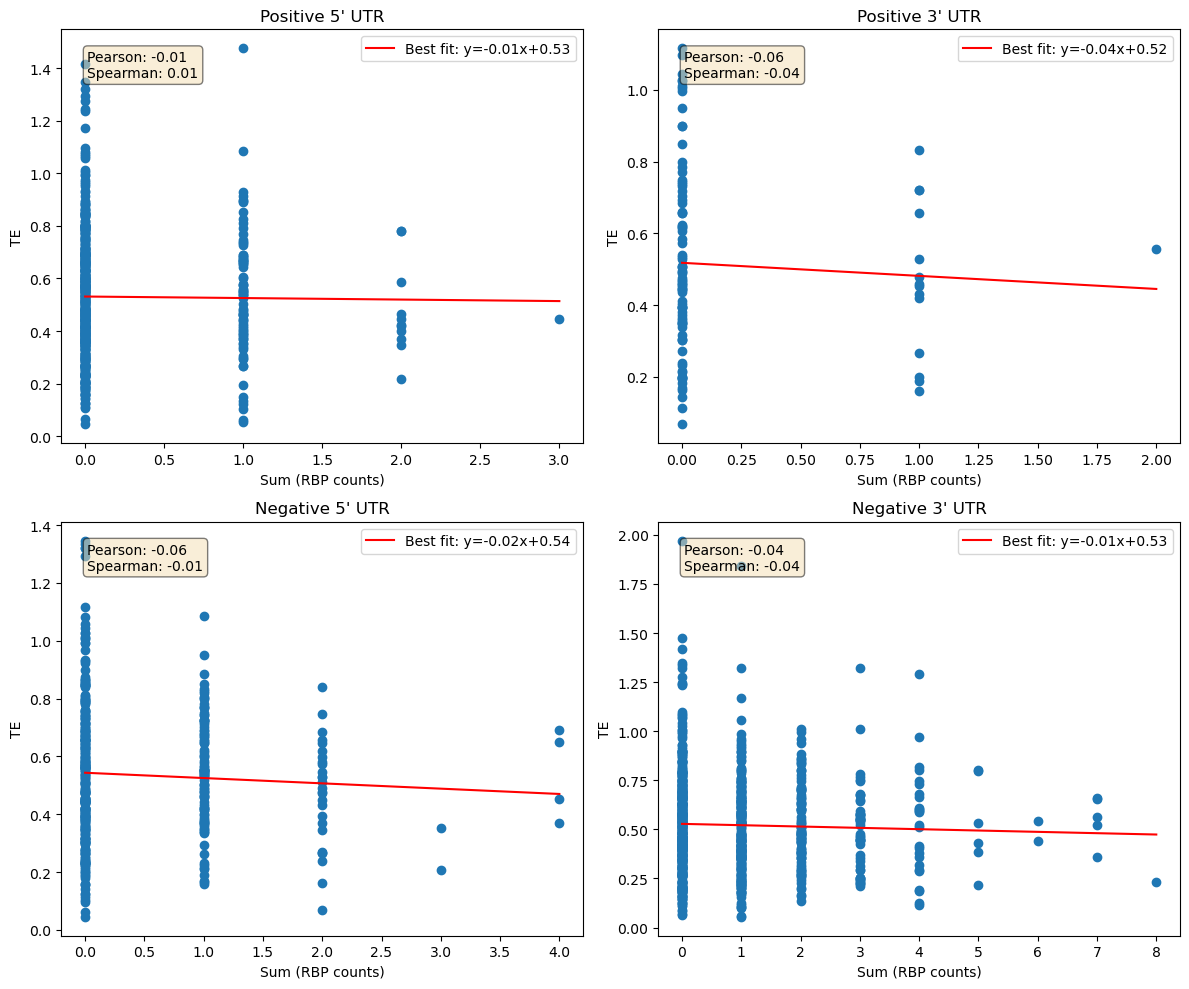

In [27]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

# Convert TE to float if necessary
pos5_collapsed['TE'] = pos5_collapsed['TE'].astype(float)
pos3_collapsed['TE'] = pos3_collapsed['TE'].astype(float)
neg5_collapsed['TE'] = neg5_collapsed['TE'].astype(float)
neg3_collapsed['TE'] = neg3_collapsed['TE'].astype(float)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
titles = ['Positive 5\' UTR', 'Positive 3\' UTR', 'Negative 5\' UTR', 'Negative 3\' UTR']
dfs = [pos5_collapsed, pos3_collapsed, neg5_collapsed, neg3_collapsed]

for i, (df, title) in enumerate(zip(dfs, titles)):
    ax = axs.flat[i]
    ax.scatter(df['sum'], df['TE'])
    
    # Calculate correlations
    pearson_corr, _ = pearsonr(df['sum'], df['TE'])
    spearman_corr, _ = spearmanr(df['sum'], df['TE'])
    
    # Fit line of best fit
    slope, intercept = np.polyfit(df['sum'], df['TE'], 1)
    line_x = np.linspace(df['sum'].min(), df['sum'].max(), 100)
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')
    
    ax.set_title(title)
    ax.set_xlabel('Sum (RBP counts)')
    ax.set_ylabel('TE')
    ax.legend()
    ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

/tmp/slurm.7402863/ipykernel_1975934/3494708202.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped.values, labels=grouped.index)
/tmp/slurm.7402863/ipykernel_1975934/3494708202.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped.values, labels=grouped.index)
/tmp/slurm.7402863/ipykernel_1975934/3494708202.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped.values, labels=grouped.index)
/tmp/slurm.7402863/ipykernel_1975934/3494708202.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; s

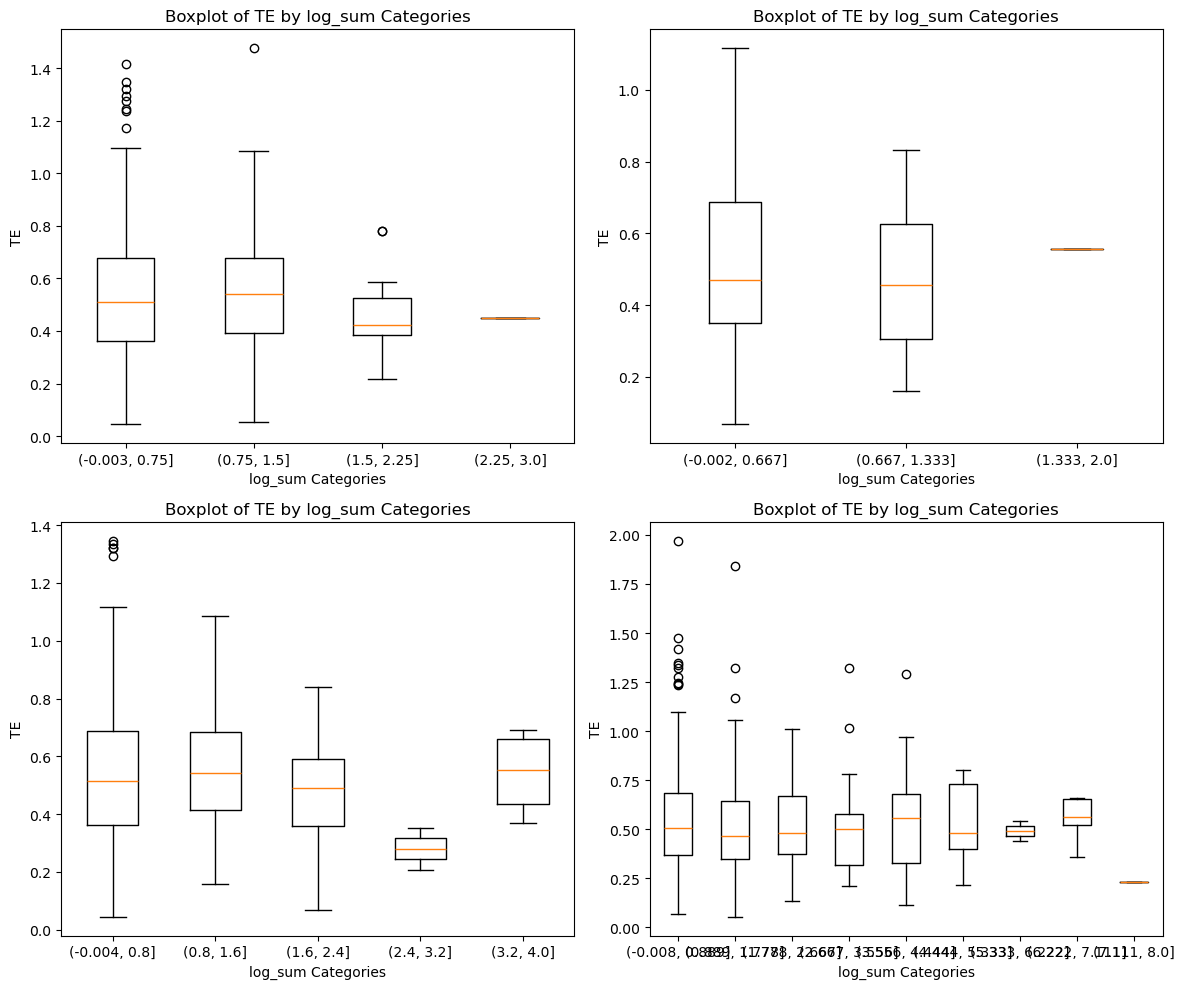

In [28]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

# Convert TE to float if necessary
pos5_collapsed['TE'] = pos5_collapsed['TE'].astype(float)
pos3_collapsed['TE'] = pos3_collapsed['TE'].astype(float)
neg5_collapsed['TE'] = neg5_collapsed['TE'].astype(float)
neg3_collapsed['TE'] = neg3_collapsed['TE'].astype(float)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
titles = ['Positive 5\' UTR', 'Positive 3\' UTR', 'Negative 5\' UTR', 'Negative 3\' UTR']
dfs = [pos5_collapsed, pos3_collapsed, neg5_collapsed, neg3_collapsed]

for i, (df, title) in enumerate(zip(dfs, titles)):
    df['sum_bins'] = pd.cut(df['sum'], bins=len(df['sum'].unique()))#, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    grouped = df.groupby('sum_bins')['TE'].apply(list)

    ax = axs.flat[i]
    ax.boxplot(grouped.values, labels=grouped.index)
    ax.set_xlabel('log_sum Categories')
    ax.set_ylabel('TE')
    ax.set_title('Boxplot of TE by log_sum Categories')

plt.tight_layout()
plt.show()


In [29]:
pos5_collapsed['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in pos5_collapsed['tr_id']]
pos3_collapsed['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in pos3_collapsed['tr_id']]
neg5_collapsed['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in neg5_collapsed['tr_id']]
neg3_collapsed['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in neg3_collapsed['tr_id']]

pos5_collapsed
merged = pd.merge(pos5_collapsed[['tr_id','sum']], pos3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
mergedNeg = pd.merge(neg5_collapsed[['tr_id','sum']], neg3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
m = pd.merge(merged, mergedNeg, on='tr_id', suffixes=('_pos', '_neg'),how='outer')
m = m.fillna(0)
m['pos_sum'] = m['sum_5utr_pos'] + m['sum_3utr_pos']
m['neg_sum'] = m['sum_5utr_neg'] + m['sum_3utr_neg']
m['above_line'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in m['tr_id']]
m

,tr_id,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,above_line
0,FBtr0070027,1.0,0.0,0.0,1.0,1.0,1.0,False
1,FBtr0070103,0.0,0.0,0.0,0.0,0.0,0.0,False
2,FBtr0070110,1.0,0.0,0.0,0.0,1.0,0.0,False
3,FBtr0070122,0.0,0.0,0.0,2.0,0.0,2.0,False
4,FBtr0070182,0.0,0.0,0.0,1.0,0.0,1.0,True
...,...,...,...,...,...,...,...,...
900,FBtr0479789,0.0,0.0,0.0,0.0,0.0,0.0,False
901,FBtr0479825,0.0,0.0,0.0,1.0,0.0,1.0,False
902,FBtr0479894,0.0,0.0,0.0,0.0,0.0,0.0,False
903,FBtr0479916,0.0,0.0,0.0,3.0,0.0,3.0,True


/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 46.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 36.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 64.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the 

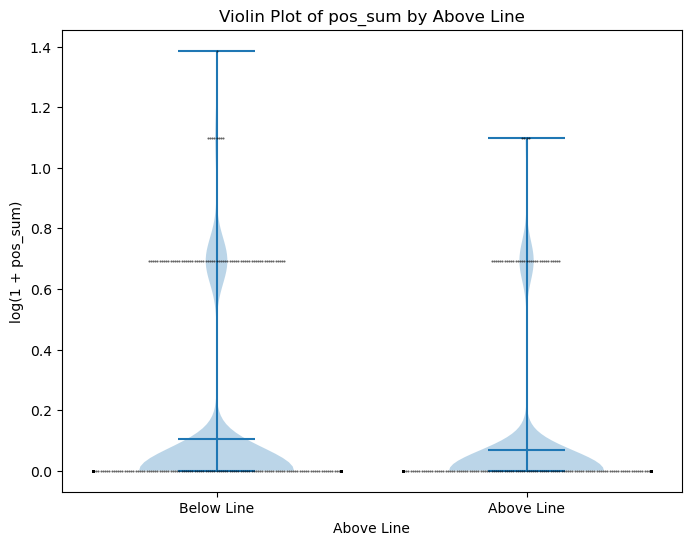

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


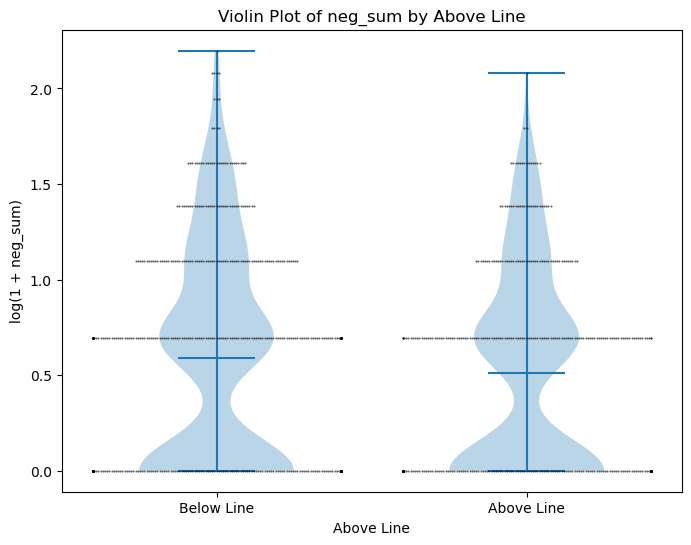

In [30]:
import seaborn as sns

import matplotlib.pyplot as plt

# Violin plot for pos_sum split by above_line
above_pos = np.log(1 + m[m['above_line'] == True]['pos_sum'])
below_pos = np.log(1 + m[m['above_line'] == False]['pos_sum'])

plt.figure(figsize=(8, 6))
plt.violinplot([below_pos, above_pos], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('log(1 + pos_sum)')
plt.title('Violin Plot of pos_sum by Above Line')
sns.swarmplot(x=['Below Line'] * len(below_pos) + ['Above Line'] * len(above_pos), y=list(below_pos) + list(above_pos), color='black', alpha=0.6, size=1.5)
plt.show()

# Violin plot for neg_sum split by above_line
above_neg = np.log(1 + m[m['above_line'] == True]['neg_sum'])
below_neg = np.log(1 + m[m['above_line'] == False]['neg_sum'])

plt.figure(figsize=(8, 6))
plt.violinplot([below_neg, above_neg], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('log(1 + neg_sum)')
plt.title('Violin Plot of neg_sum by Above Line')
sns.swarmplot(x=['Below Line'] * len(below_neg) + ['Above Line'] * len(above_neg), y=list(below_neg) + list(above_neg), color='black', alpha=0.6, size=1.5)
plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 46.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 37.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


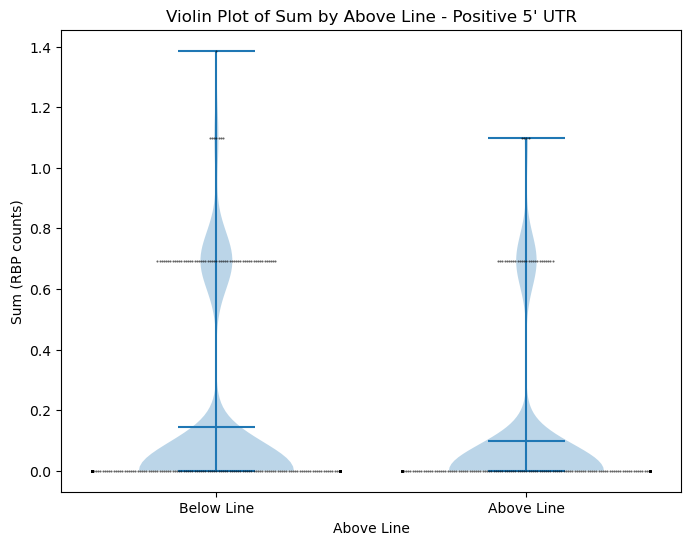

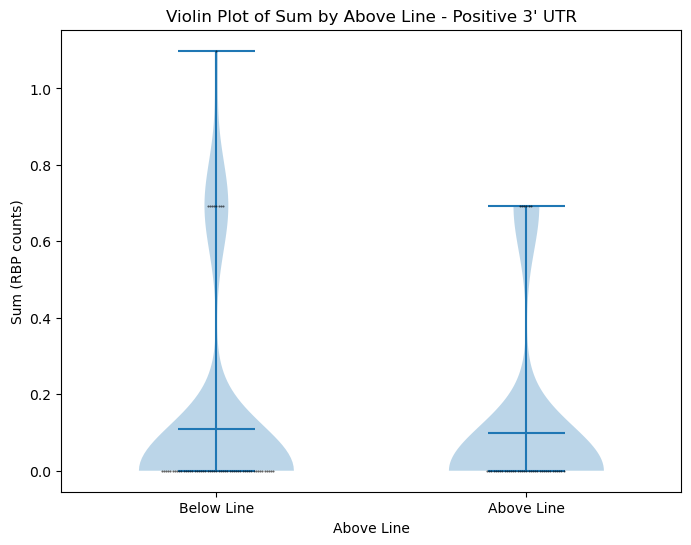

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 17.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


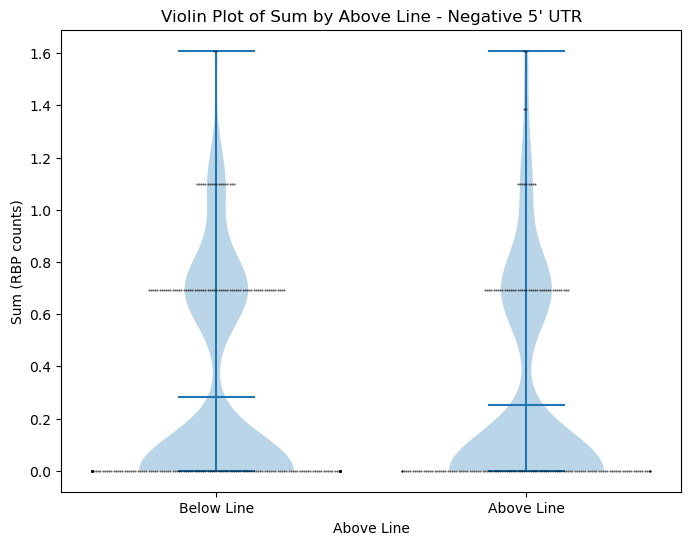

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 21.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


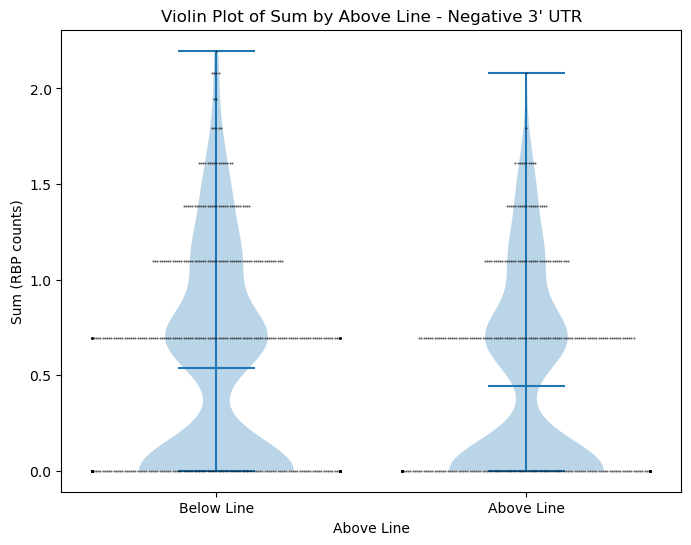

In [31]:

import seaborn as sns

import matplotlib.pyplot as plt

for df,title in zip([pos5_collapsed, pos3_collapsed, neg5_collapsed, neg3_collapsed], ['Positive 5\' UTR', 'Positive 3\' UTR', 'Negative 5\' UTR', 'Negative 3\' UTR']):
    #print(title)
    # Group the 'sum' values by 'above_line'
    above = np.log(1+df[df['above_line'] == True]['sum'])
    below = np.log(1+df[df['above_line'] == False]['sum'])

    # Create violin plot
    plt.figure(figsize=(8, 6))
    plt.violinplot([below, above], positions=[0, 1], showmeans=True)
    plt.xticks([0, 1], ['Below Line', 'Above Line'])
    plt.xlabel('Above Line')
    plt.ylabel('Sum (RBP counts)')
    plt.title(f'Violin Plot of Sum by Above Line - {title}')

    # Add swarm plot on top
    sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

    plt.show()

# # Group the 'sum' values by 'above_line'
# above = np.log(1+tr_df[tr_df['above_line'] == True]['sum'])
# below = np.log(1+tr_df[tr_df['above_line'] == False]['sum'])
# 
# # Create violin plot
# plt.figure(figsize=(8, 6))
# plt.violinplot([below, above], positions=[0, 1], showmeans=True)
# plt.xticks([0, 1], ['Below Line', 'Above Line'])
# plt.xlabel('Above Line')
# plt.ylabel('Sum (RBP counts)')
# plt.title('Violin Plot of Sum by Above Line')
# 
# # Add swarm plot on top
# sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)
# 
# plt.show()

In [32]:
pos5_collapsed['above_line_full'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in pos5_collapsed['tr_id']]
pos3_collapsed['above_line_full'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in pos3_collapsed['tr_id']]
neg5_collapsed['above_line_full'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in neg5_collapsed['tr_id']]
neg3_collapsed['above_line_full'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in neg3_collapsed['tr_id']]

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 41.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the s

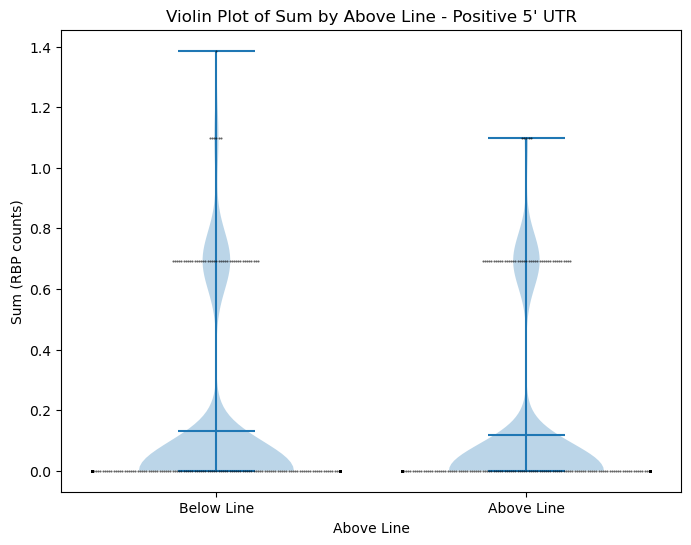

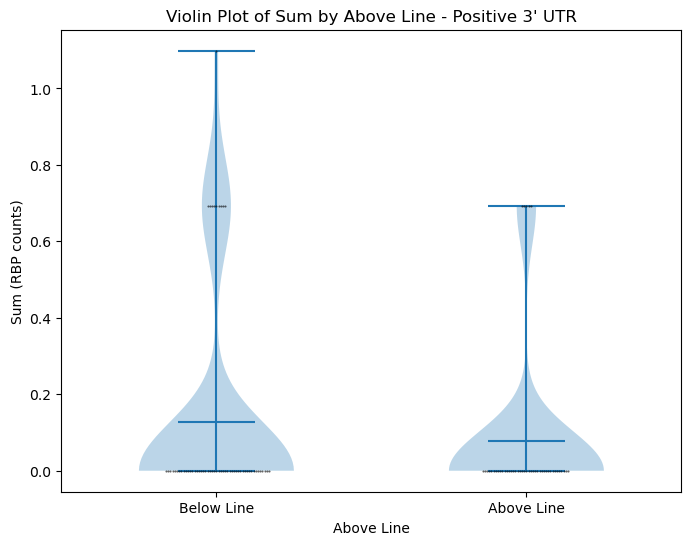

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 16.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


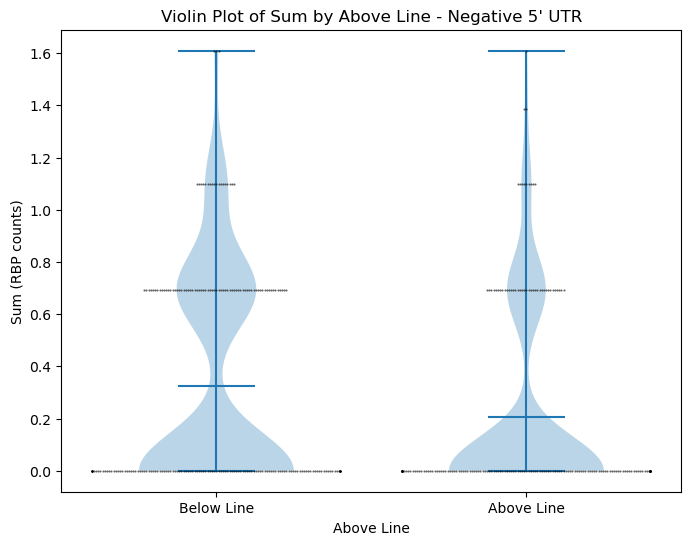

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


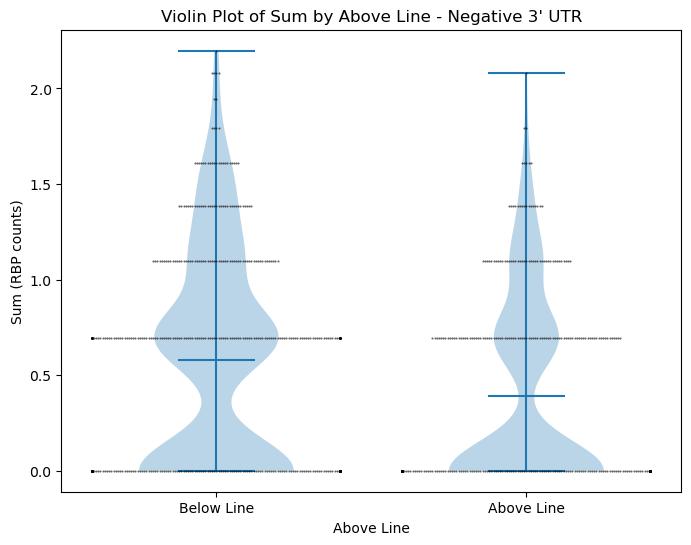

In [33]:

import seaborn as sns

import matplotlib.pyplot as plt

for df,title in zip([pos5_collapsed, pos3_collapsed, neg5_collapsed, neg3_collapsed], ['Positive 5\' UTR', 'Positive 3\' UTR', 'Negative 5\' UTR', 'Negative 3\' UTR']):
    #print(title)
    # Group the 'sum' values by 'above_line'
    above = np.log(1+df[df['above_line_full'] == True]['sum'])
    below = np.log(1+df[df['above_line_full'] == False]['sum'])

    # Create violin plot
    plt.figure(figsize=(8, 6))
    plt.violinplot([below, above], positions=[0, 1], showmeans=True)
    plt.xticks([0, 1], ['Below Line', 'Above Line'])
    plt.xlabel('Above Line')
    plt.ylabel('Sum (RBP counts)')
    plt.title(f'Violin Plot of Sum by Above Line - {title}')

    # Add swarm plot on top
    sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

    plt.show()

In [34]:
merged = pd.merge(pos5_collapsed[['tr_id','sum']], pos3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
mergedNeg = pd.merge(neg5_collapsed[['tr_id','sum']], neg3_collapsed[['tr_id','sum']], on='tr_id', suffixes=('_5utr', '_3utr'),how='outer')
m = pd.merge(merged, mergedNeg, on='tr_id', suffixes=('_pos', '_neg'),how='outer')
m = m.fillna(0)
m['pos_sum'] = m['sum_5utr_pos'] + m['sum_3utr_pos']
m['neg_sum'] = m['sum_5utr_neg'] + m['sum_3utr_neg']
m['above_line'] = [fullpreds.loc[tr_id, 'above_line'] if tr_id in fullpreds.index else None for tr_id in m['tr_id']]
m['ratio'] = (m['neg_sum'] + 1) / (m['pos_sum'] + 1)
m

,tr_id,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,above_line,ratio
0,FBtr0070027,1.0,0.0,0.0,1.0,1.0,1.0,True,1.0
1,FBtr0070103,0.0,0.0,0.0,0.0,0.0,0.0,True,1.0
2,FBtr0070110,1.0,0.0,0.0,0.0,1.0,0.0,False,0.5
3,FBtr0070122,0.0,0.0,0.0,2.0,0.0,2.0,False,3.0
4,FBtr0070182,0.0,0.0,0.0,1.0,0.0,1.0,True,2.0
...,...,...,...,...,...,...,...,...,...
900,FBtr0479789,0.0,0.0,0.0,0.0,0.0,0.0,True,1.0
901,FBtr0479825,0.0,0.0,0.0,1.0,0.0,1.0,False,2.0
902,FBtr0479894,0.0,0.0,0.0,0.0,0.0,0.0,False,1.0
903,FBtr0479916,0.0,0.0,0.0,3.0,0.0,3.0,False,4.0


/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 19.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 22.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


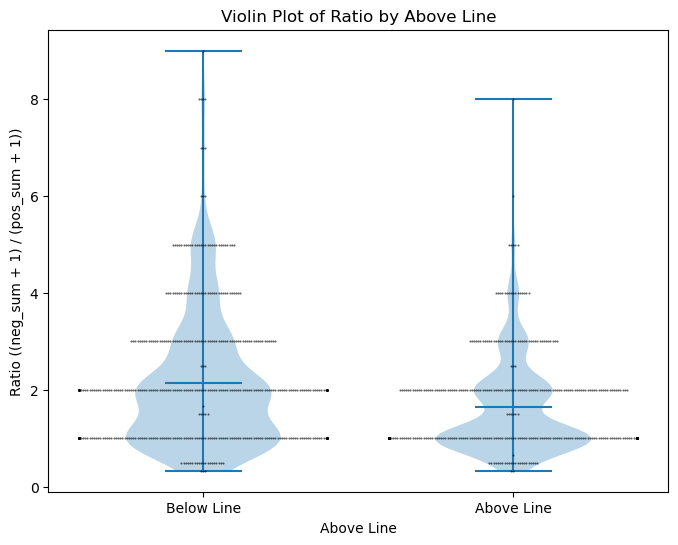

In [35]:
import seaborn as sns

import matplotlib.pyplot as plt

# Split the 'ratio' values by 'above_line'
above_ratio = m[m['above_line'] == True]['ratio']
below_ratio = m[m['above_line'] == False]['ratio']

# Create violin plot
plt.figure(figsize=(8, 6))
plt.violinplot([below_ratio, above_ratio], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('Ratio ((neg_sum + 1) / (pos_sum + 1))')
plt.title('Violin Plot of Ratio by Above Line')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below_ratio) + ['Above Line'] * len(above_ratio), y=list(below_ratio) + list(above_ratio), color='black', alpha=0.6, size=1.5)

plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 46.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 36.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 65.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 59.9% of the points cannot be placed; you may want to decrease the 

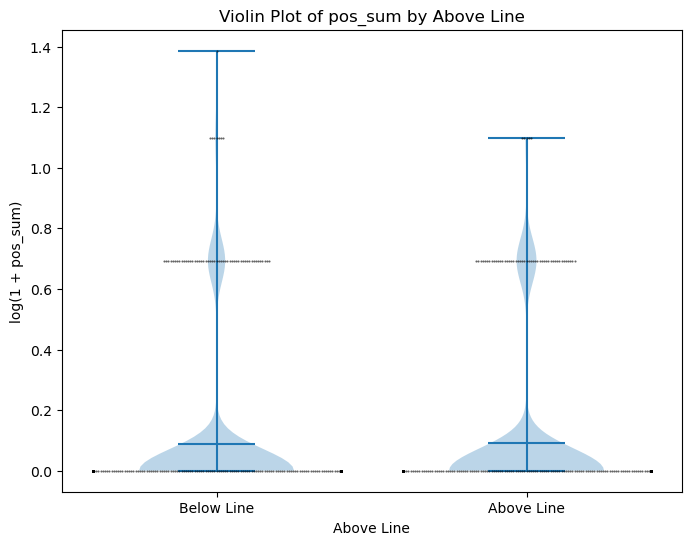

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 22.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 26.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


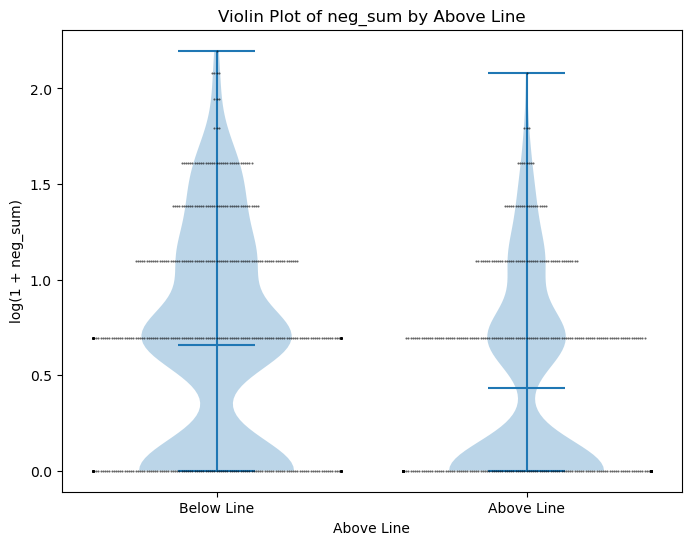

In [36]:
import seaborn as sns

import matplotlib.pyplot as plt

# Violin plot for pos_sum split by above_line
above_pos = np.log(1 + m[m['above_line'] == True]['pos_sum'])
below_pos = np.log(1 + m[m['above_line'] == False]['pos_sum'])

plt.figure(figsize=(8, 6))
plt.violinplot([below_pos, above_pos], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('log(1 + pos_sum)')
plt.title('Violin Plot of pos_sum by Above Line')
sns.swarmplot(x=['Below Line'] * len(below_pos) + ['Above Line'] * len(above_pos), y=list(below_pos) + list(above_pos), color='black', alpha=0.6, size=1.5)
plt.show()

# Violin plot for neg_sum split by above_line
above_neg = np.log(1 + m[m['above_line'] == True]['neg_sum'])
below_neg = np.log(1 + m[m['above_line'] == False]['neg_sum'])

plt.figure(figsize=(8, 6))
plt.violinplot([below_neg, above_neg], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line')
plt.ylabel('log(1 + neg_sum)')
plt.title('Violin Plot of neg_sum by Above Line')
sns.swarmplot(x=['Below Line'] * len(below_neg) + ['Above Line'] * len(above_neg), y=list(below_neg) + list(above_neg), color='black', alpha=0.6, size=1.5)
plt.show()

In [37]:
tr_df

alt_id,EIF-2ALPHA,PABP,ROX8,sum,normalized,TE,above_line,above_line_full,log_sum,log_sum_bins,log_normalized
tr_id,,,,,,,,,,,
FBtr0005088,1,3,1,5,0.007862,0.420582,False,False,1.791759,"(1.723, 1.826]",0.007862
FBtr0070027,2,4,2,8,0.012140,0.054332,False,True,2.197225,"(2.135, 2.238]",0.012140
FBtr0070103,1,1,1,3,0.005245,0.334942,False,True,1.386294,"(1.311, 1.414]",0.005245
FBtr0070110,1,3,1,5,0.005800,0.668479,False,False,1.791759,"(1.723, 1.826]",0.005800
FBtr0070122,1,3,0,4,0.010811,0.483116,False,False,1.609438,"(1.517, 1.62]",0.010811
...,...,...,...,...,...,...,...,...,...,...,...
FBtr0479909,1,9,3,13,0.009306,0.574857,False,False,2.639057,"(2.547, 2.65]",0.009306
FBtr0479916,1,1,5,7,0.007202,0.251356,True,False,2.079442,"(2.032, 2.135]",0.007202
FBtr0480509,6,9,10,25,0.011241,0.524301,False,False,3.258097,"(3.165, 3.268]",0.011241


In [38]:
m

,tr_id,sum_5utr_pos,sum_3utr_pos,sum_5utr_neg,sum_3utr_neg,pos_sum,neg_sum,above_line,ratio
0,FBtr0070027,1.0,0.0,0.0,1.0,1.0,1.0,True,1.0
1,FBtr0070103,0.0,0.0,0.0,0.0,0.0,0.0,True,1.0
2,FBtr0070110,1.0,0.0,0.0,0.0,1.0,0.0,False,0.5
3,FBtr0070122,0.0,0.0,0.0,2.0,0.0,2.0,False,3.0
4,FBtr0070182,0.0,0.0,0.0,1.0,0.0,1.0,True,2.0
...,...,...,...,...,...,...,...,...,...
900,FBtr0479789,0.0,0.0,0.0,0.0,0.0,0.0,True,1.0
901,FBtr0479825,0.0,0.0,0.0,1.0,0.0,1.0,False,2.0
902,FBtr0479894,0.0,0.0,0.0,0.0,0.0,0.0,False,1.0
903,FBtr0479916,0.0,0.0,0.0,3.0,0.0,3.0,False,4.0


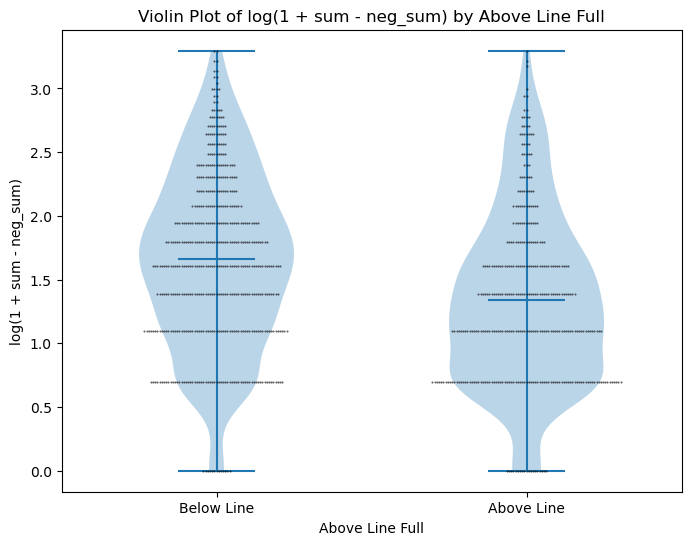

In [39]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Merge tr_df with m's neg_sum, keeping all rows from tr_df
merged_df = pd.merge(tr_df, m[['tr_id', 'neg_sum']], on='tr_id', how='left')

# Create new column: sum - neg_sum
merged_df['sum_minus_neg'] = merged_df['sum'] - merged_df['neg_sum']

# Log transform for plotting
merged_df['log_sum_minus_neg'] = np.log(1 + merged_df['sum_minus_neg'])

# Group by above_line_full and plot
above = merged_df[merged_df['above_line_full'] == True]['log_sum_minus_neg']
below = merged_df[merged_df['above_line_full'] == False]['log_sum_minus_neg']

plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line Full')
plt.ylabel('log(1 + sum - neg_sum)')
plt.title('Violin Plot of log(1 + sum - neg_sum) by Above Line Full')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

plt.show()

In [40]:
merged_df

,tr_id,EIF-2ALPHA,PABP,ROX8,sum,normalized,TE,above_line,above_line_full,log_sum,log_sum_bins,log_normalized,neg_sum,sum_minus_neg,log_sum_minus_neg
0,FBtr0005088,1,3,1,5,0.007862,0.420582,False,False,1.791759,"(1.723, 1.826]",0.007862,1.0,4.0,1.609438
1,FBtr0070027,2,4,2,8,0.012140,0.054332,False,True,2.197225,"(2.135, 2.238]",0.012140,1.0,7.0,2.079442
2,FBtr0070103,1,1,1,3,0.005245,0.334942,False,True,1.386294,"(1.311, 1.414]",0.005245,0.0,3.0,1.386294
3,FBtr0070110,1,3,1,5,0.005800,0.668479,False,False,1.791759,"(1.723, 1.826]",0.005800,0.0,5.0,1.791759
4,FBtr0070122,1,3,0,4,0.010811,0.483116,False,False,1.609438,"(1.517, 1.62]",0.010811,2.0,2.0,1.098612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,FBtr0479909,1,9,3,13,0.009306,0.574857,False,False,2.639057,"(2.547, 2.65]",0.009306,2.0,11.0,2.484907
838,FBtr0479916,1,1,5,7,0.007202,0.251356,True,False,2.079442,"(2.032, 2.135]",0.007202,3.0,4.0,1.609438
839,FBtr0480509,6,9,10,25,0.011241,0.524301,False,False,3.258097,"(3.165, 3.268]",0.011241,3.0,22.0,3.135494
840,FBtr0481643,1,4,7,12,0.008856,0.532470,False,True,2.564949,"(2.547, 2.65]",0.008856,5.0,7.0,2.079442


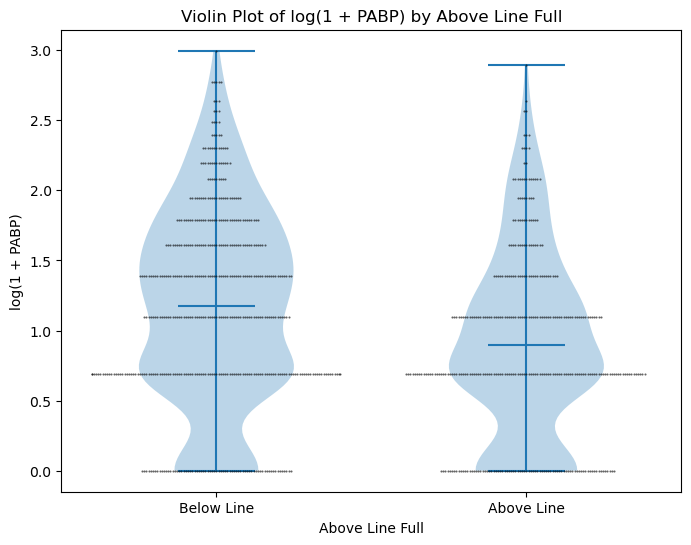

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


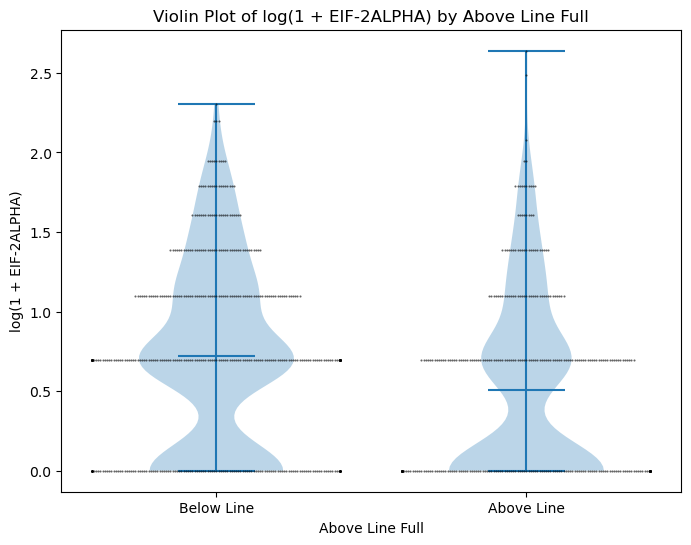

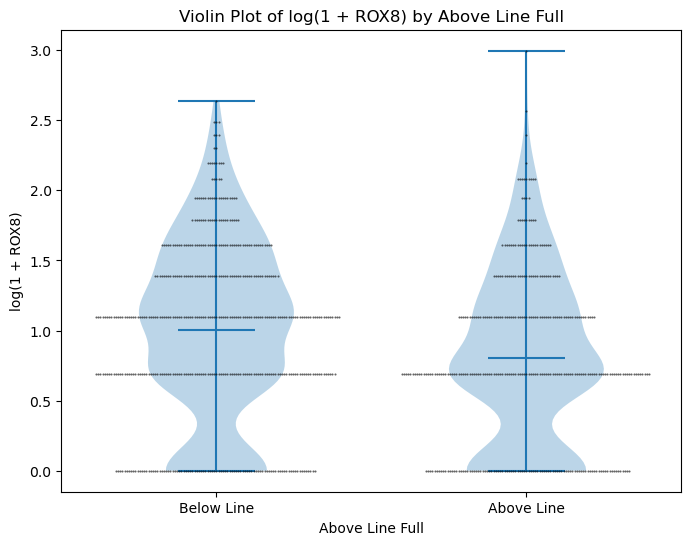

In [41]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Assuming merged_df is available from previous cells
# Columns to plot: PABP, EIF-2ALPHA, ROX8
columns_to_plot = ['PABP', 'EIF-2ALPHA', 'ROX8']

for col in columns_to_plot:
    # Group the column values by 'above_line_full'
    above = np.log(1 + merged_df[merged_df['above_line_full'] == True][col])
    below = np.log(1 + merged_df[merged_df['above_line_full'] == False][col])

    # Create violin plot
    plt.figure(figsize=(8, 6))
    plt.violinplot([below, above], positions=[0, 1], showmeans=True)
    plt.xticks([0, 1], ['Below Line', 'Above Line'])
    plt.xlabel('Above Line Full')
    plt.ylabel(f'log(1 + {col})')
    plt.title(f'Violin Plot of log(1 + {col}) by Above Line Full')

    # Add swarm plot on top
    sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

    plt.show()

In [42]:
sequences_dict_len['FBtr0005088']

636

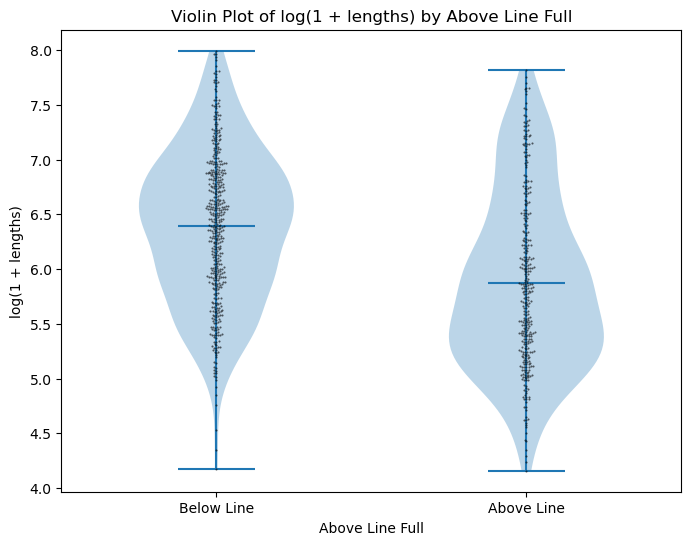

In [43]:
import seaborn as sns

merged_df['lengths'] = [sequences_dict_len.get(tr_id, None) for tr_id in merged_df['tr_id']]

import matplotlib.pyplot as plt

above = np.log(1 + merged_df[merged_df['above_line_full'] == True]['lengths'])
below = np.log(1 + merged_df[merged_df['above_line_full'] == False]['lengths'])

plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line Full')
plt.ylabel('log(1 + lengths)')
plt.title('Violin Plot of log(1 + lengths) by Above Line Full')

sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 7.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


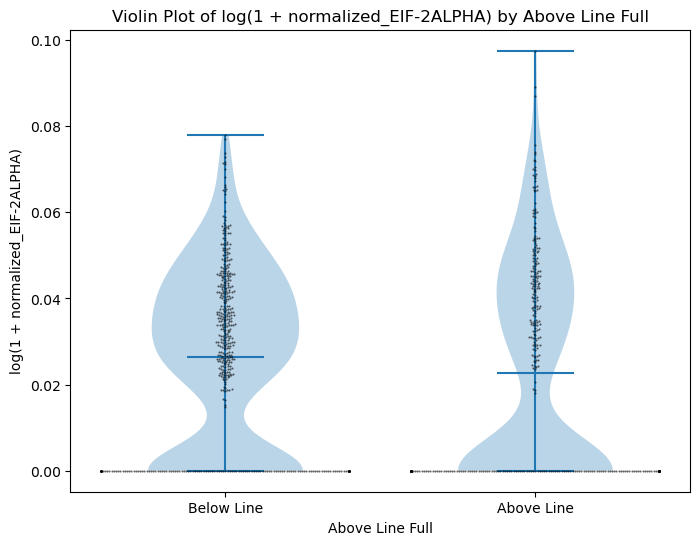

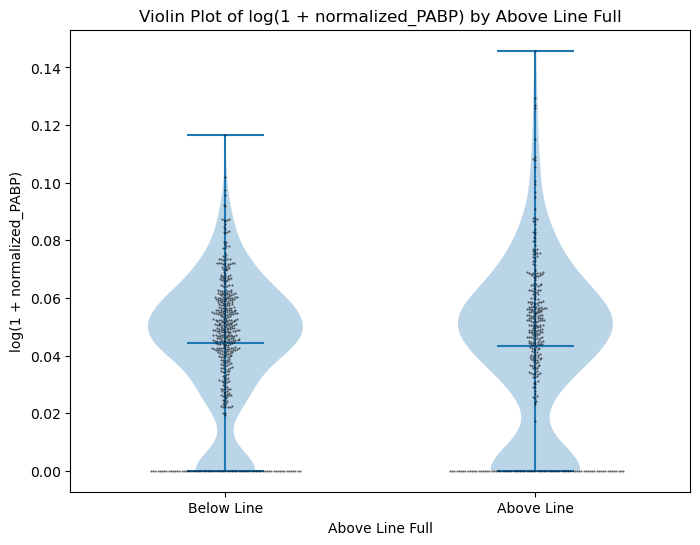

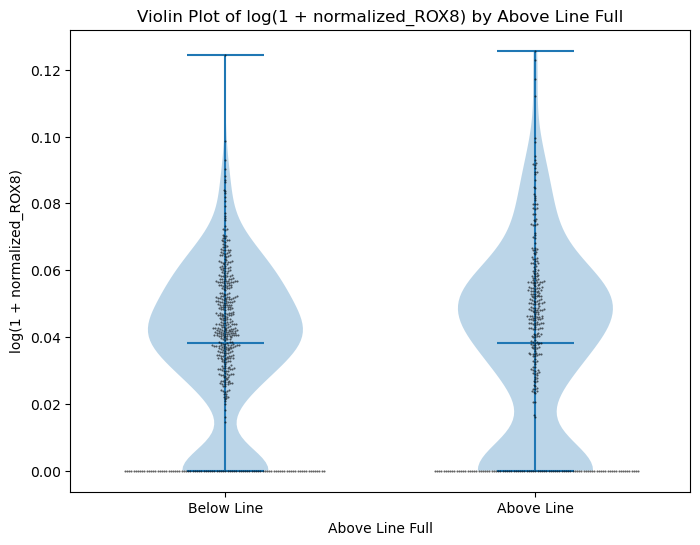

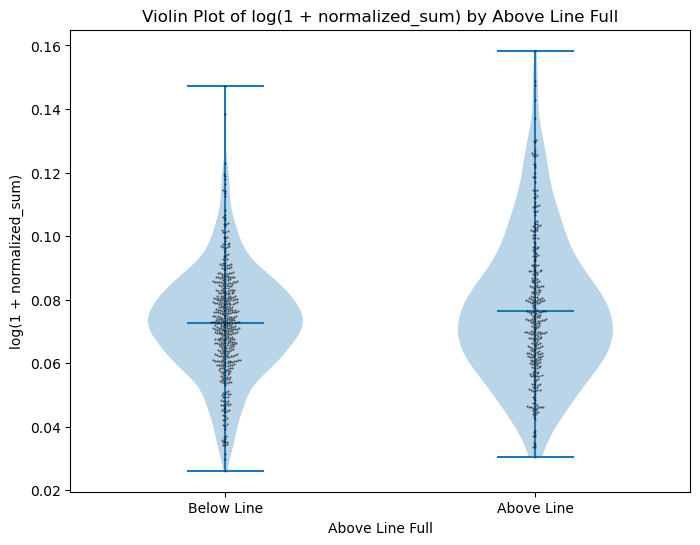

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


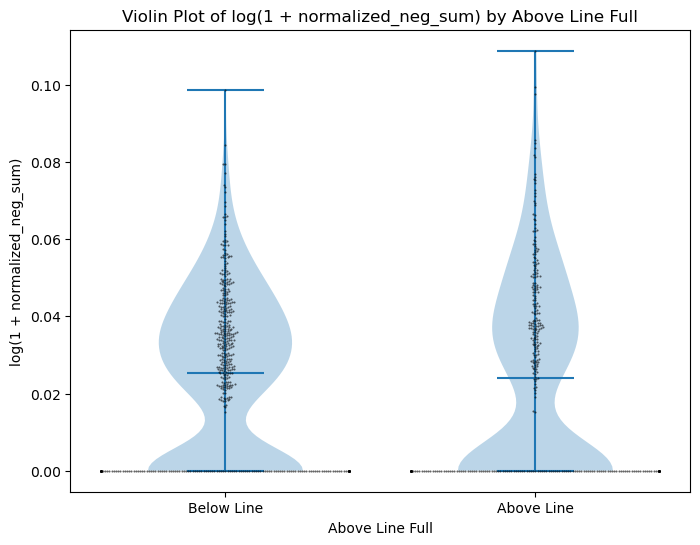

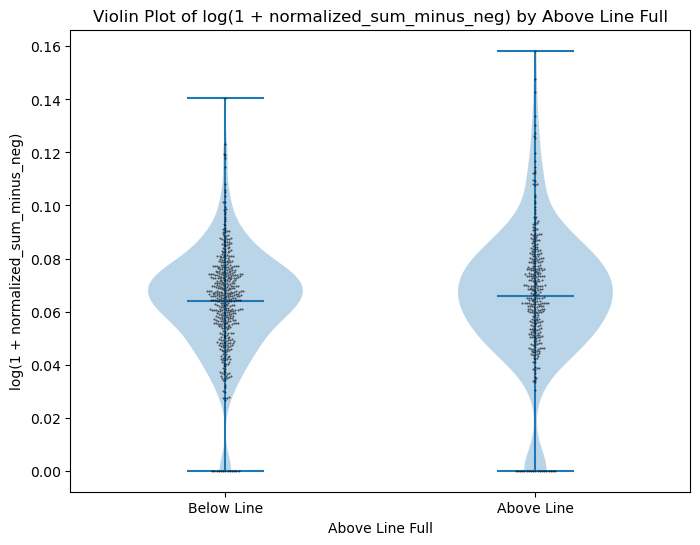

In [44]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Assuming merged_df is available from previous cells
# Normalize by lengths
merged_df['normalized_EIF-2ALPHA'] = np.log(1+ merged_df['EIF-2ALPHA'] ) / np.sqrt(merged_df['lengths'])
merged_df['normalized_PABP'] = np.log(1+ merged_df['PABP'] ) / np.sqrt(merged_df['lengths'])
merged_df['normalized_ROX8'] = np.log(1+ merged_df['ROX8'] ) / np.sqrt(merged_df['lengths'])
merged_df['normalized_sum'] = np.log(1+ merged_df['sum'] ) / np.sqrt(merged_df['lengths'])
merged_df['normalized_neg_sum'] = np.log(1+ merged_df['neg_sum'] ) / np.sqrt(merged_df['lengths'])
merged_df['normalized_sum_minus_neg'] = np.log(1+ merged_df['sum_minus_neg'] ) / np.sqrt(merged_df['lengths'])

# Columns to plot
columns_to_plot = ['normalized_EIF-2ALPHA', 'normalized_PABP', 'normalized_ROX8', 'normalized_sum', 'normalized_neg_sum', 'normalized_sum_minus_neg']

for col in columns_to_plot:
    # Group by above_line_full
    above = merged_df[merged_df['above_line_full'] == True][col]
    below = merged_df[merged_df['above_line_full'] == False][col]

    # Create violin plot
    plt.figure(figsize=(8, 6))
    plt.violinplot([below, above], positions=[0, 1], showmeans=True)
    plt.xticks([0, 1], ['Below Line', 'Above Line'])
    plt.xlabel('Above Line Full')
    plt.ylabel(f'log(1 + {col})')
    plt.title(f'Violin Plot of log(1 + {col}) by Above Line Full')

    # Add swarm plot on top
    sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

    plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


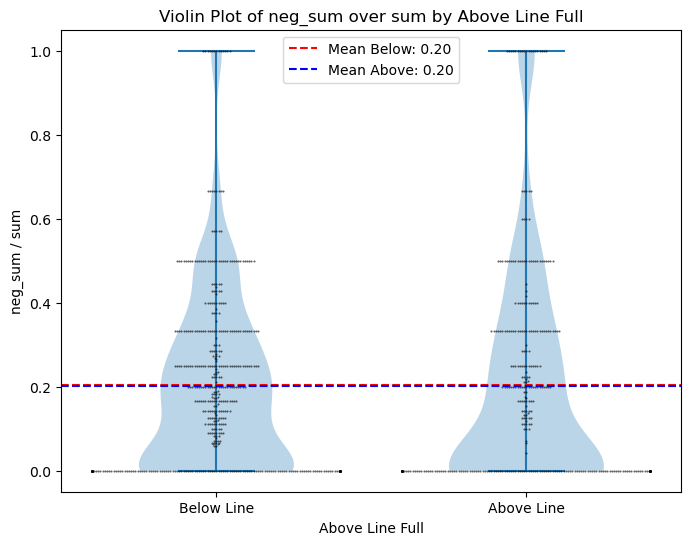

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


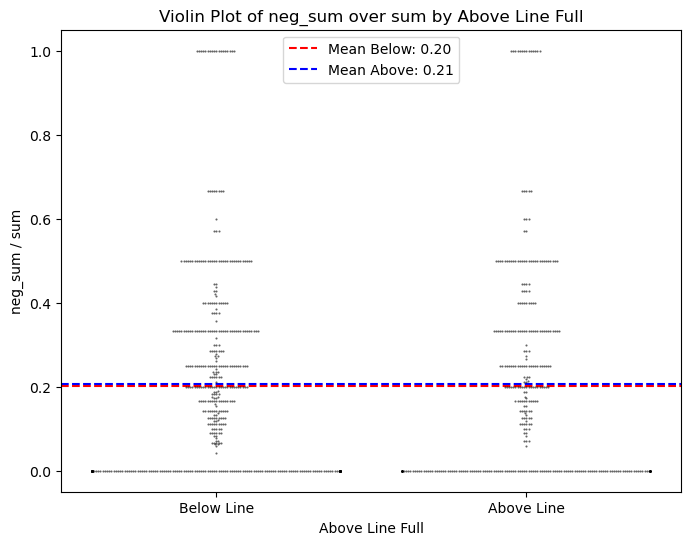

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming merged_df is available from previous cells
# Compute the ratio of neg_sum over sum, filtering out zero sum to avoid division by zero
merged_df_filtered = merged_df[merged_df['sum'] > 0].copy()
merged_df_filtered['ratio_neg_over_sum'] = merged_df_filtered['neg_sum'] / merged_df_filtered['sum']

# Group by above_line_full
above = merged_df_filtered[merged_df_filtered['above_line_full'] == True]['ratio_neg_over_sum']
below = merged_df_filtered[merged_df_filtered['above_line_full'] == False]['ratio_neg_over_sum']

# Create violin plot
plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1])
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line Full')
plt.ylabel('neg_sum / sum')
plt.title('Violin Plot of neg_sum over sum by Above Line Full')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)
# Add horizontal lines for the means of each group
mean_below = below.mean()
mean_above = above.mean()
plt.axhline(y=mean_below, color='red', linestyle='--', label=f'Mean Below: {mean_below:.2f}')
plt.axhline(y=mean_above, color='blue', linestyle='--', label=f'Mean Above: {mean_above:.2f}')
plt.legend()
plt.show()

# Group by above_line
above = merged_df_filtered[merged_df_filtered['above_line'] == True]['ratio_neg_over_sum']
below = merged_df_filtered[merged_df_filtered['above_line'] == False]['ratio_neg_over_sum']

# Create violin plot
plt.figure(figsize=(8, 6))
plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line Full')
plt.ylabel('neg_sum / sum')
plt.title('Violin Plot of neg_sum over sum by Above Line Full')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)
# Add horizontal lines for the means of each group
mean_below = below.mean()
mean_above = above.mean()
plt.axhline(y=mean_below, color='red', linestyle='--', label=f'Mean Below: {mean_below:.2f}')
plt.axhline(y=mean_above, color='blue', linestyle='--', label=f'Mean Above: {mean_above:.2f}')
plt.legend()

plt.show()

/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/mr01-home01/m65338lb/.local/share/mamba/envs/rayTune/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


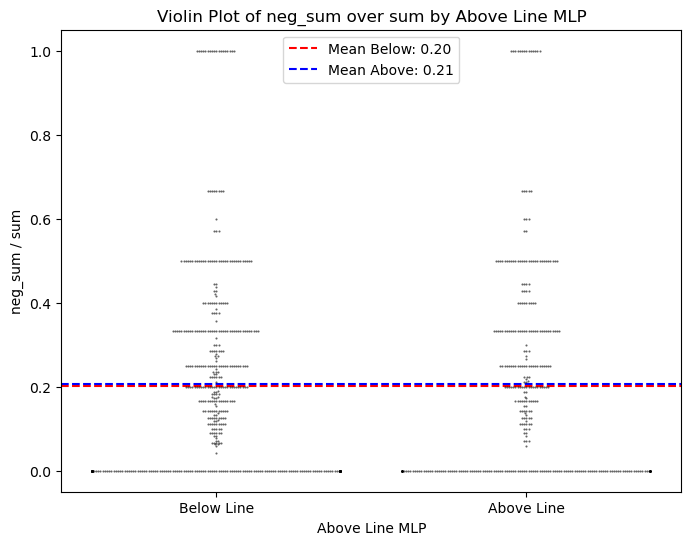

In [47]:
import seaborn as sns

import matplotlib.pyplot as plt

# Add a new column 'above_line_mlp' to m using preds['above_line']
merged_df_filtered['above_line_mlp'] = [preds.loc[tr_id, 'above_line'] if tr_id in preds.index else None for tr_id in merged_df_filtered['tr_id']]

# Plot the ratio by above_line_mlp
above = merged_df_filtered[merged_df_filtered['above_line_mlp'] == True]['ratio_neg_over_sum']
below = merged_df_filtered[merged_df_filtered['above_line_mlp'] == False]['ratio_neg_over_sum']

# Create violin plot
plt.figure(figsize=(8, 6))
#plt.violinplot([below, above], positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Below Line', 'Above Line'])
plt.xlabel('Above Line MLP')
plt.ylabel('neg_sum / sum')
plt.title('Violin Plot of neg_sum over sum by Above Line MLP')

# Add swarm plot on top
sns.swarmplot(x=['Below Line'] * len(below) + ['Above Line'] * len(above), y=list(below) + list(above), color='black', alpha=0.6, size=1.5)

# Add horizontal lines for the means of each group
mean_below = below.mean()
mean_above = above.mean()
plt.axhline(y=mean_below, color='red', linestyle='--', label=f'Mean Below: {mean_below:.2f}')
plt.axhline(y=mean_above, color='blue', linestyle='--', label=f'Mean Above: {mean_above:.2f}')
plt.legend()

plt.show()

In [48]:
merged_df

,tr_id,EIF-2ALPHA,PABP,ROX8,sum,normalized,TE,above_line,above_line_full,log_sum,...,neg_sum,sum_minus_neg,log_sum_minus_neg,lengths,normalized_EIF-2ALPHA,normalized_PABP,normalized_ROX8,normalized_sum,normalized_neg_sum,normalized_sum_minus_neg
0,FBtr0005088,1,3,1,5,0.007862,0.420582,False,False,1.791759,...,1.0,4.0,1.609438,636,0.027485,0.054970,0.027485,0.071048,0.027485,0.063818
1,FBtr0070027,2,4,2,8,0.012140,0.054332,False,True,2.197225,...,1.0,7.0,2.079442,659,0.042796,0.062695,0.042796,0.085592,0.027001,0.081004
2,FBtr0070103,1,1,1,3,0.005245,0.334942,False,True,1.386294,...,0.0,3.0,1.386294,572,0.028982,0.028982,0.028982,0.057964,0.000000,0.057964
3,FBtr0070110,1,3,1,5,0.005800,0.668479,False,False,1.791759,...,0.0,5.0,1.791759,862,0.023609,0.047217,0.023609,0.061028,0.000000,0.061028
4,FBtr0070122,1,3,0,4,0.010811,0.483116,False,False,1.609438,...,2.0,2.0,1.098612,370,0.036035,0.072070,0.000000,0.083671,0.057114,0.057114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,FBtr0479909,1,9,3,13,0.009306,0.574857,False,False,2.639057,...,2.0,11.0,2.484907,1397,0.018545,0.061605,0.037090,0.070607,0.029393,0.066483
838,FBtr0479916,1,1,5,7,0.007202,0.251356,True,False,2.079442,...,3.0,4.0,1.609438,972,0.022233,0.022233,0.057471,0.066698,0.044465,0.051623
839,FBtr0480509,6,9,10,25,0.011241,0.524301,False,False,3.258097,...,3.0,22.0,3.135494,2224,0.041262,0.048826,0.050847,0.069087,0.029396,0.066487
840,FBtr0481643,1,4,7,12,0.008856,0.532470,False,True,2.564949,...,5.0,7.0,2.079442,1355,0.018830,0.043722,0.056491,0.069680,0.048675,0.056491


/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


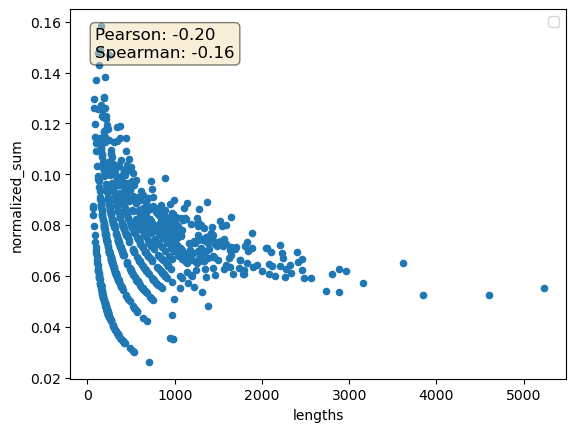

/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


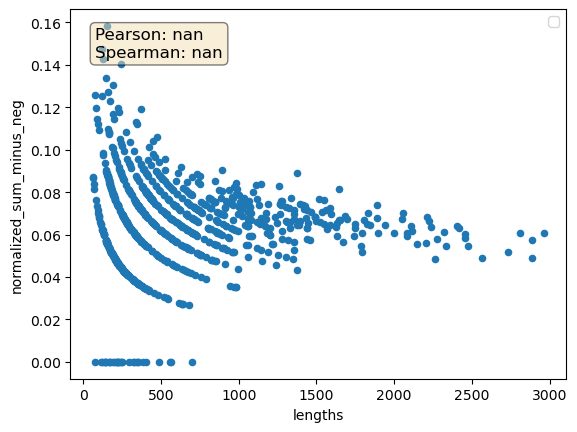

/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


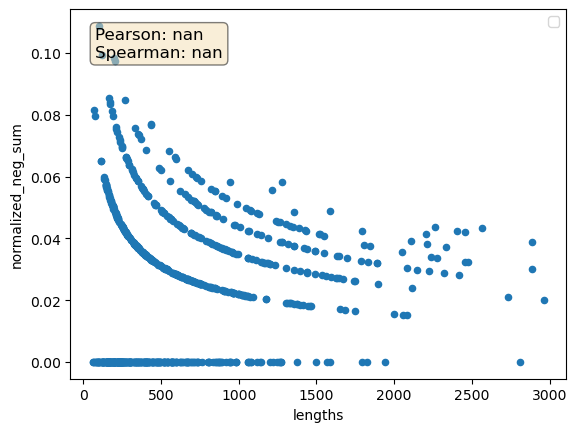

/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


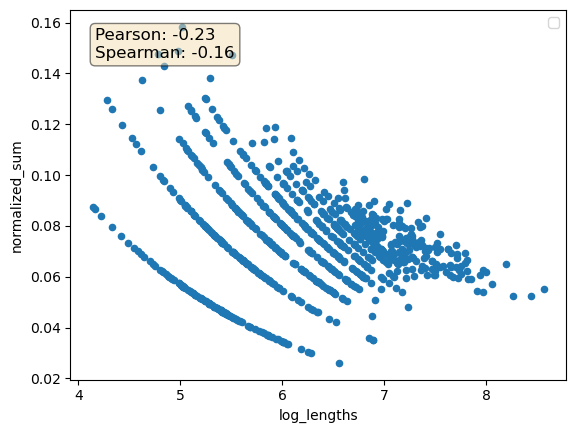

/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


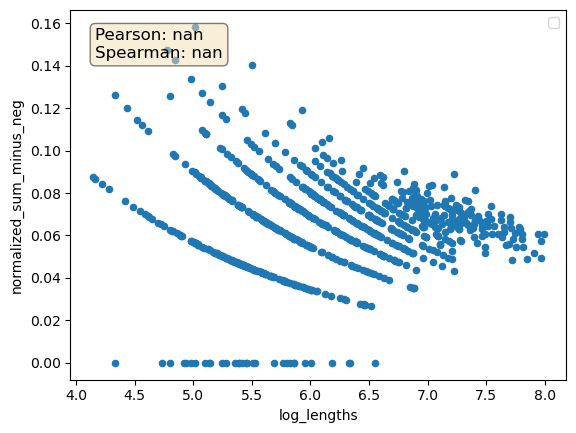

/tmp/slurm.7402863/ipykernel_1975934/1813135911.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


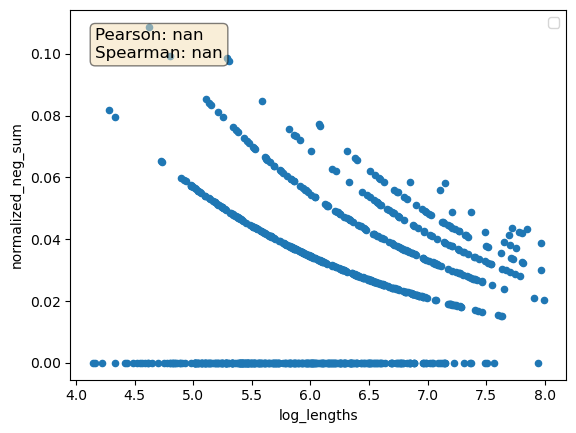

In [49]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

# Assuming merged_df is available from previous cells
# Columns to plot against length: normalized_sum, neg_sum, sum_minus_neg
columns_to_plot = ['normalized_sum', 'normalized_sum_minus_neg', 'normalized_neg_sum']

for col in columns_to_plot:
    # Calculate correlations
    pearson_corr, _ = pearsonr(merged_df['lengths'], merged_df[col])
    spearman_corr, _ = spearmanr(merged_df['lengths'], merged_df[col])
    
    # # Fit line of best fit
    # slope, intercept = np.polyfit(merged_df['lengths'], merged_df[col], 1)
    # line_x = np.linspace(merged_df['lengths'].min(), merged_df['lengths'].max(), 100)
    # line_y = slope * line_x + intercept
    
    # Plot scatter plot
    ax = merged_df.plot.scatter(x='lengths', y=col)
    
    # # Add line of best fit
    # ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')
    
    # Annotate correlations
    ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.legend()
    plt.show()

merged_df['log_lengths'] = np.log(merged_df['lengths'])
for col in columns_to_plot:
    # Calculate correlations
    pearson_corr, _ = pearsonr(np.log(merged_df['lengths']), merged_df[col])
    spearman_corr, _ = spearmanr(np.log(merged_df['lengths']), merged_df[col])
    
    # # Fit line of best fit
    # slope, intercept = np.polyfit(merged_df['lengths'], merged_df[col], 1)
    # line_x = np.linspace(merged_df['lengths'].min(), merged_df['lengths'].max(), 100)
    # line_y = slope * line_x + intercept
    
    # Plot scatter plot
    ax = merged_df.plot.scatter(x='log_lengths', y=col)
    
    # # Add line of best fit
    # ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')
    
    # Annotate correlations
    ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.legend()
    plt.show()

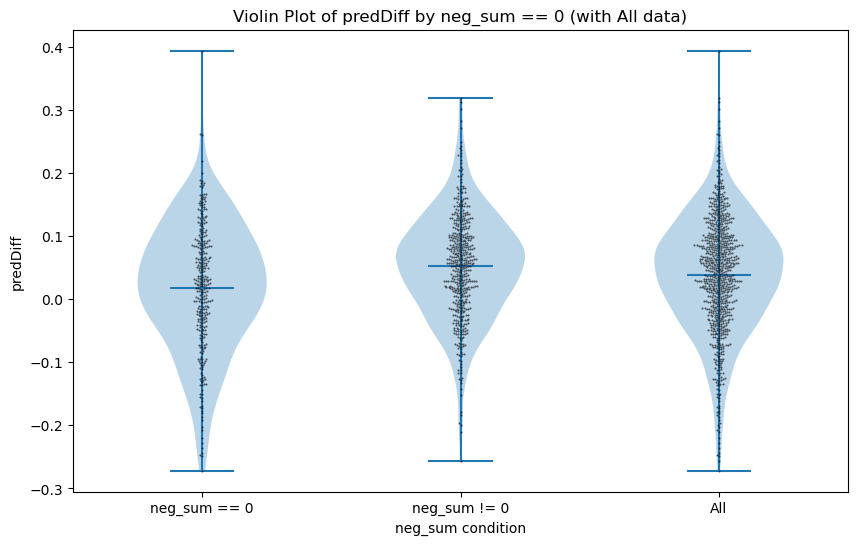

In [50]:
import seaborn as sns

merged_df['predDiff'] = [predMerged.loc[tr_id, 'predDiff'] if tr_id in predMerged.index else None for tr_id in merged_df['tr_id']]

import matplotlib.pyplot as plt

# Split predDiff by whether neg_sum == 0
zero_neg = merged_df[merged_df['neg_sum'] == 0]['predDiff']
nonzero_neg = merged_df[merged_df['neg_sum'] != 0]['predDiff']
all_predDiff = merged_df['predDiff']

# Create violin plot
plt.figure(figsize=(10, 6))
plt.violinplot([zero_neg.dropna(), nonzero_neg.dropna(), all_predDiff.dropna()], positions=[0, 1, 2], showmeans=True)
plt.xticks([0, 1, 2], ['neg_sum == 0', 'neg_sum != 0', 'All'])
plt.xlabel('neg_sum condition')
plt.ylabel('predDiff')
plt.title('Violin Plot of predDiff by neg_sum == 0 (with All data)')

# Add swarm plot on top
sns.swarmplot(x=['neg_sum == 0'] * len(zero_neg.dropna()) + ['neg_sum != 0'] * len(nonzero_neg.dropna()) + ['All'] * len(all_predDiff.dropna()), 
              y=list(zero_neg.dropna()) + list(nonzero_neg.dropna()) + list(all_predDiff.dropna()), color='black', alpha=0.6, size=1.5)

plt.show()

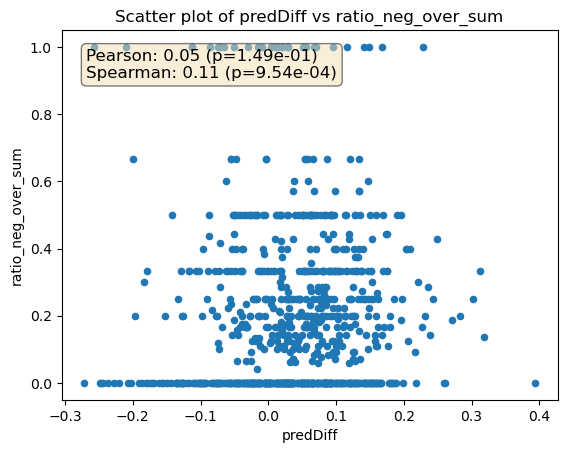

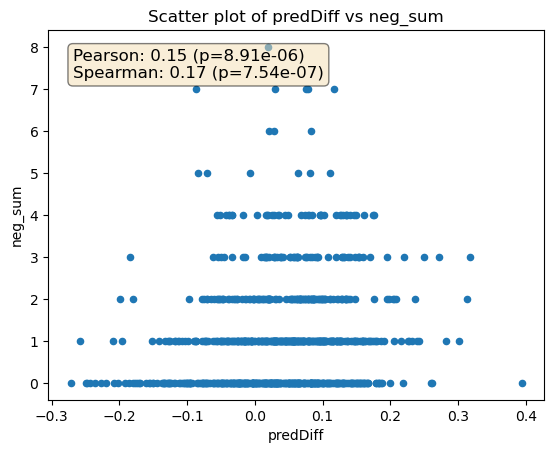

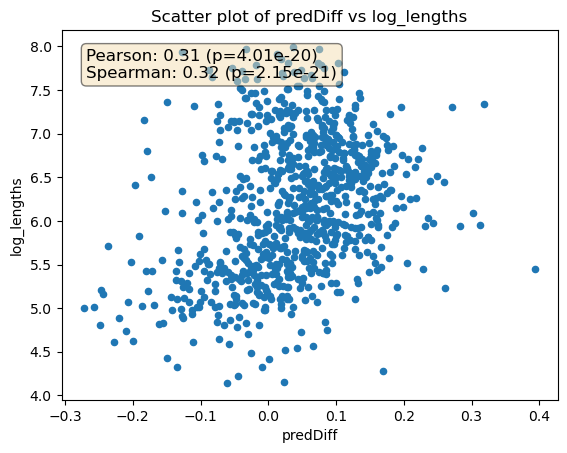

In [51]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

merged_df['ratio_neg_over_sum'] = merged_df['neg_sum'] / merged_df['sum']
ax = merged_df.plot.scatter(y='ratio_neg_over_sum', x='predDiff')
plt.ylabel('ratio_neg_over_sum')
plt.xlabel('predDiff')
plt.title('Scatter plot of predDiff vs ratio_neg_over_sum')
# Calculate correlations
pearson_corr, pearson_p = pearsonr(merged_df['ratio_neg_over_sum'].dropna(), merged_df['predDiff'].dropna())
spearman_corr, spearman_p = spearmanr(merged_df['ratio_neg_over_sum'].dropna(), merged_df['predDiff'].dropna())

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f} (p={pearson_p:.2e})\nSpearman: {spearman_corr:.2f} (p={spearman_p:.2e})', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

ax = merged_df.plot.scatter(y='neg_sum', x='predDiff')
plt.ylabel('neg_sum')
plt.xlabel('predDiff')
plt.title('Scatter plot of predDiff vs neg_sum')

# Calculate correlations
pearson_corr, pearson_p = pearsonr(merged_df['neg_sum'].dropna(), merged_df['predDiff'].dropna())
spearman_corr, spearman_p = spearmanr(merged_df['neg_sum'].dropna(), merged_df['predDiff'].dropna())

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f} (p={pearson_p:.2e})\nSpearman: {spearman_corr:.2f} (p={spearman_p:.2e})', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

tmp = merged_df[~merged_df['predDiff'].isna()]
ax = tmp.plot.scatter(y='log_lengths', x='predDiff')
plt.ylabel('log_lengths')
plt.xlabel('predDiff')
plt.title('Scatter plot of predDiff vs log_lengths')

# Calculate correlations
pearson_corr, pearson_p = pearsonr(tmp['log_lengths'].dropna(), tmp['predDiff'].dropna())
spearman_corr, spearman_p = spearmanr(tmp['log_lengths'].dropna(), tmp['predDiff'].dropna())

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f} (p={pearson_p:.2e})\nSpearman: {spearman_corr:.2f} (p={spearman_p:.2e})', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

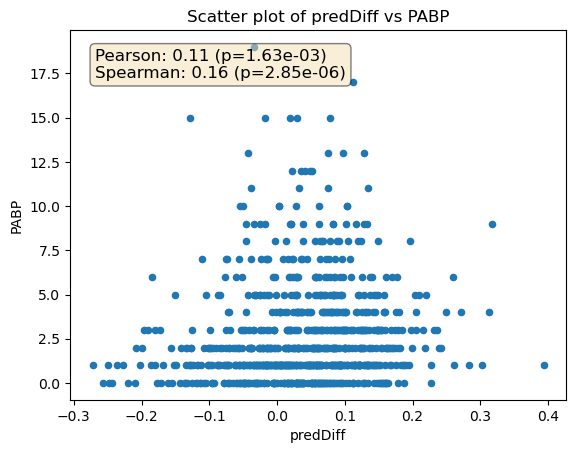

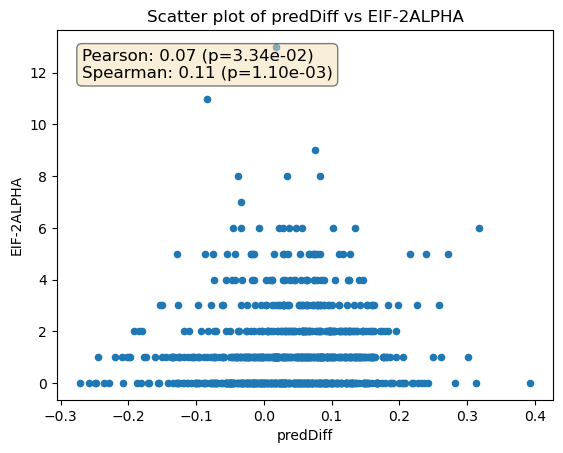

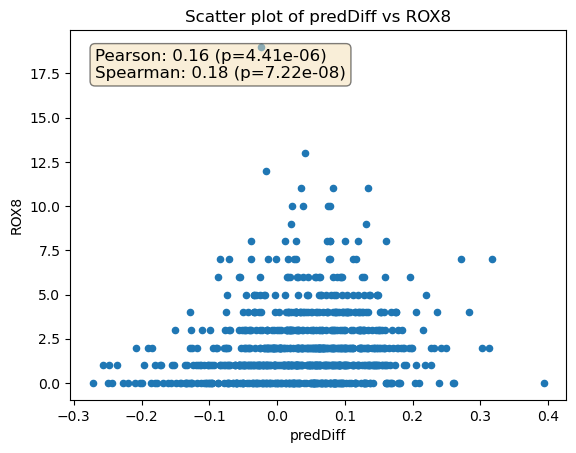

In [52]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

cols = ['PABP', 'EIF-2ALPHA', 'ROX8']

tmp = merged_df[~merged_df['predDiff'].isna()]
for col in cols:
    ax = tmp.plot.scatter(y=col, x='predDiff')
    plt.ylabel(col)
    plt.xlabel('predDiff')
    plt.title(f'Scatter plot of predDiff vs {col}')
    # Calculate correlations
    pearson_corr, pearson_p = pearsonr(tmp[col].dropna(), tmp['predDiff'].dropna())
    spearman_corr, spearman_p = spearmanr(tmp[col].dropna(), tmp['predDiff'].dropna())

    # Annotate correlations
    ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f} (p={pearson_p:.2e})\nSpearman: {spearman_corr:.2f} (p={spearman_p:.2e})', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.show()

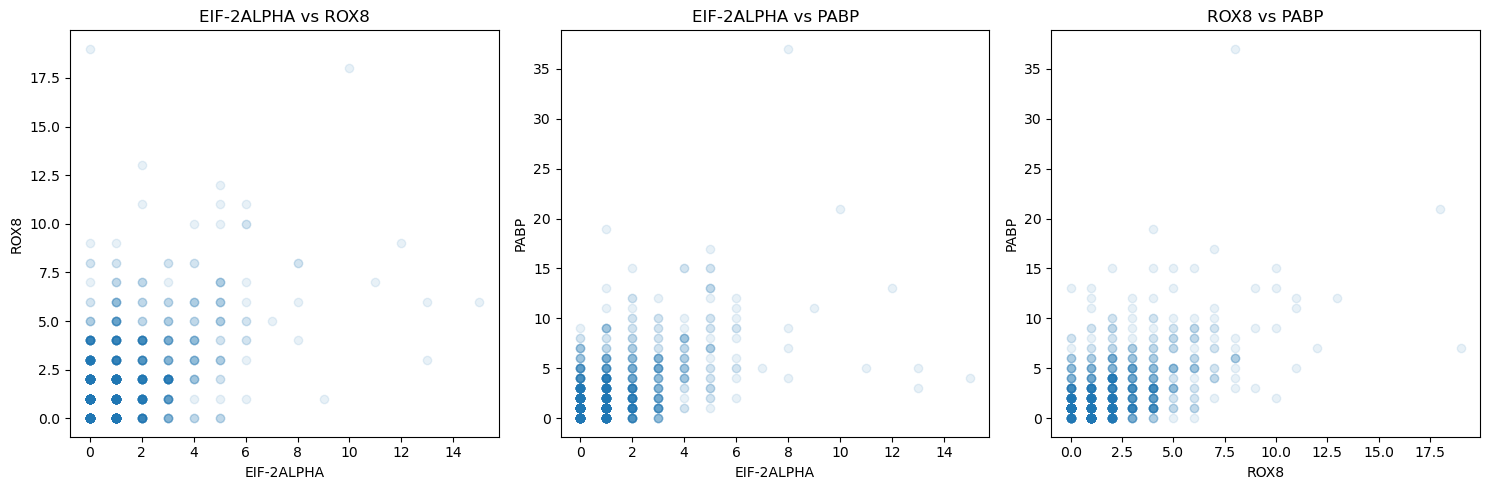

In [53]:
import matplotlib.pyplot as plt

# Scatter plots for pairwise comparisons of RBP counts
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# EIF-2ALPHA vs ROX8
axs[0].scatter(tr_df['EIF-2ALPHA'], tr_df['ROX8'], alpha=0.1)
axs[0].set_xlabel('EIF-2ALPHA')
axs[0].set_ylabel('ROX8')
axs[0].set_title('EIF-2ALPHA vs ROX8')

# EIF-2ALPHA vs PABP
axs[1].scatter(tr_df['EIF-2ALPHA'], tr_df['PABP'], alpha=0.1)
axs[1].set_xlabel('EIF-2ALPHA')
axs[1].set_ylabel('PABP')
axs[1].set_title('EIF-2ALPHA vs PABP')

# ROX8 vs PABP
axs[2].scatter(tr_df['ROX8'], tr_df['PABP'], alpha=0.1)
axs[2].set_xlabel('ROX8')
axs[2].set_ylabel('PABP')
axs[2].set_title('ROX8 vs PABP')

plt.tight_layout()
plt.show()

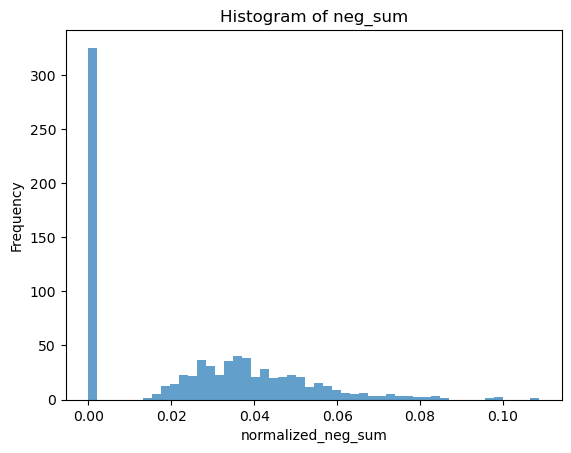

In [54]:
import matplotlib.pyplot as plt

merged_df['normalized_neg_sum'].plot.hist(bins=50, alpha=0.7)
plt.xlabel('normalized_neg_sum')
plt.ylabel('Frequency')
plt.title('Histogram of neg_sum')
plt.show()

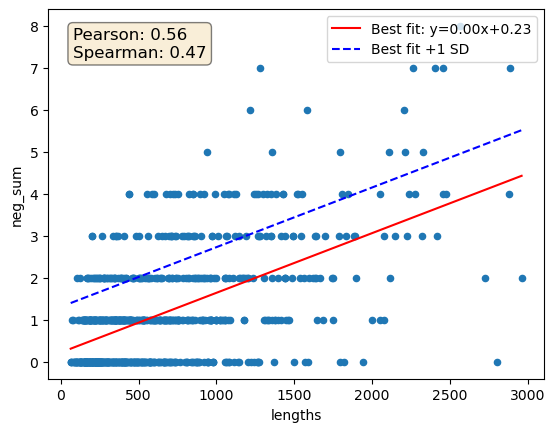

In [59]:
import numpy as np
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt

tmp = merged_df[~merged_df['lengths'].isna() & ~merged_df['neg_sum'].isna()]

# Assuming merged_df is available from previous cells
# Plot scatter plot of neg_sum vs lengths
ax = tmp.plot.scatter(x='lengths', y='neg_sum')

# Calculate correlations
pearson_corr, _ = pearsonr(tmp['lengths'], tmp['neg_sum'])
spearman_corr, _ = spearmanr(tmp['lengths'], tmp['neg_sum'])

# Fit line of best fit
slope, intercept = np.polyfit(tmp['lengths'], tmp['neg_sum'], 1)
line_x = np.linspace(tmp['lengths'].min(), tmp['lengths'].max(), 100)
line_y = slope * line_x + intercept

# Calculate residuals and standard deviation
residuals = tmp['neg_sum'] - (slope * tmp['lengths'] + intercept)
std_dev = np.std(residuals)

# Line one standard deviation above
line_y_above = line_y + std_dev

# Add line of best fit
ax.plot(line_x, line_y, color='red', label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')

# Add line one std above
ax.plot(line_x, line_y_above, color='blue', linestyle='--', label=f'Best fit +1 SD')

# Annotate correlations
ax.text(0.05, 0.95, f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}', 
    transform=ax.transAxes, fontsize=12, verticalalignment='top', 
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
plt.show()

In [61]:
tmp['above_best_fit_plus_1sd'] = tmp['neg_sum'] > (slope * tmp['lengths'] + intercept + std_dev)
tmp

/tmp/slurm.7402863/ipykernel_1975934/1053205585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['above_best_fit_plus_1sd'] = tmp['neg_sum'] > (slope * tmp['lengths'] + intercept + std_dev)


,tr_id,EIF-2ALPHA,PABP,ROX8,sum,normalized,TE,above_line,above_line_full,log_sum,...,normalized_PABP,normalized_ROX8,normalized_sum,normalized_neg_sum,normalized_sum_minus_neg,log_lengths,predDiff,ratio_neg_over_sum,above_custom_line,above_best_fit_plus_1sd
0,FBtr0005088,1,3,1,5,0.007862,0.420582,False,False,1.791759,...,0.054970,0.027485,0.071048,0.027485,0.063818,6.455199,0.057146,0.200000,False,False
1,FBtr0070027,2,4,2,8,0.012140,0.054332,False,True,2.197225,...,0.062695,0.042796,0.085592,0.027001,0.081004,6.490724,0.004451,0.125000,False,False
2,FBtr0070103,1,1,1,3,0.005245,0.334942,False,True,1.386294,...,0.028982,0.028982,0.057964,0.000000,0.057964,6.349139,-0.061849,0.000000,False,False
3,FBtr0070110,1,3,1,5,0.005800,0.668479,False,False,1.791759,...,0.047217,0.023609,0.061028,0.000000,0.061028,6.759255,-0.098298,0.000000,False,False
4,FBtr0070122,1,3,0,4,0.010811,0.483116,False,False,1.609438,...,0.072070,0.000000,0.083671,0.057114,0.057114,5.913503,0.127942,0.500000,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,FBtr0479909,1,9,3,13,0.009306,0.574857,False,False,2.639057,...,0.061605,0.037090,0.070607,0.029393,0.066483,7.242082,0.020725,0.153846,False,False
838,FBtr0479916,1,1,5,7,0.007202,0.251356,True,False,2.079442,...,0.022233,0.057471,0.066698,0.044465,0.051623,6.879356,0.119459,0.428571,True,True
839,FBtr0480509,6,9,10,25,0.011241,0.524301,False,False,3.258097,...,0.048826,0.050847,0.069087,0.029396,0.066487,7.707063,0.037856,0.120000,False,False
840,FBtr0481643,1,4,7,12,0.008856,0.532470,False,True,2.564949,...,0.043722,0.056491,0.069680,0.048675,0.056491,7.211557,-0.071302,0.416667,True,True


In [63]:
tmp[tmp['above_best_fit_plus_1sd'] == True]['tr_id'].values

array(['FBtr0070122', 'FBtr0070392', 'FBtr0070756', 'FBtr0070794',
       'FBtr0070798', 'FBtr0070821', 'FBtr0070837', 'FBtr0071091',
       'FBtr0071166', 'FBtr0071368', 'FBtr0071654', 'FBtr0071907',
       'FBtr0071922', 'FBtr0072062', 'FBtr0072120', 'FBtr0072129',
       'FBtr0072173', 'FBtr0072262', 'FBtr0072315', 'FBtr0072519',
       'FBtr0072551', 'FBtr0072589', 'FBtr0072622', 'FBtr0072789',
       'FBtr0072805', 'FBtr0073457', 'FBtr0073542', 'FBtr0073609',
       'FBtr0073668', 'FBtr0074217', 'FBtr0074825', 'FBtr0074922',
       'FBtr0075042', 'FBtr0075312', 'FBtr0075591', 'FBtr0075967',
       'FBtr0076029', 'FBtr0076219', 'FBtr0076441', 'FBtr0076613',
       'FBtr0077016', 'FBtr0077100', 'FBtr0077145', 'FBtr0077500',
       'FBtr0078009', 'FBtr0078011', 'FBtr0078638', 'FBtr0078766',
       'FBtr0079233', 'FBtr0079349', 'FBtr0079960', 'FBtr0080038',
       'FBtr0080313', 'FBtr0080492', 'FBtr0080570', 'FBtr0081001',
       'FBtr0081073', 'FBtr0081158', 'FBtr0081246', 'FBtr00815

In [88]:
# Install required package if needed: pip install goatools

import pandas as pd
from collections import defaultdict
from gprofiler import GProfiler

# Initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Get the transcript IDs that are above the best fit line + 1 SD
sg_affected_transcripts = tmp[tmp['above_best_fit_plus_1sd'] == True]['tr_id'].values
# Convert transcript IDs (FBtr) to gene IDs (FBgn) using g:Profiler
converted = gp.convert(organism='dmelanogaster', query=list(sg_affected_transcripts), target_namespace='FLYBASENAME_GENE')

# Extract the converted gene IDs
gene_ids = converted['converted'].dropna().unique().tolist()

# Update sg_affected_transcripts to use gene IDs
sg_affected_transcripts = gene_ids

converted = gp.convert(organism='dmelanogaster', query=tmp['tr_id'].tolist(), target_namespace='FLYBASENAME_GENE')
background_gene_ids = converted['converted'].dropna().unique().tolist()


print(f"Number of transcripts with high stress granule binding: {len(sg_affected_transcripts)}")

# Run GO enrichment analysis
# organism='dmelanogaster' for Drosophila
go_results = gp.profile(
    organism='dmelanogaster',
    query=list(sg_affected_transcripts),
    sources=['GO:BP'],  # Biological Process, Molecular Function, Cellular Component
    user_threshold=0.05,  # p-value threshold
    #significance_threshold_method='fdr',  # Use FDR correction
    no_evidences=False,
    all_results=True,
    background=background_gene_ids  # Use all background gene IDs
)


if go_results is not None and len(go_results) > 0:
    # Sort by p-value
    go_results = go_results.sort_values('p_value')
    
    print(f"\nFound {len(go_results)} significantly enriched GO terms")
    print("\nTop 20 enriched GO terms:")
    print(go_results[['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']].head(20))
    
    # Save full results
    go_results.to_csv('sg_high_binding_GO_enrichment.csv', index=False)
    print("\nFull results saved to 'sg_high_binding_GO_enrichment.csv'")
    
    # Create summary by GO category
    print("\n=== Summary by GO Category ===")
    for source in ['GO:BP', 'GO:MF', 'GO:CC']:
        subset = go_results[go_results['source'] == source]
        if len(subset) > 0:
            print(f"\n{source}: {len(subset)} terms")
            print(subset[['name', 'p_value', 'intersection_size']].head(5))
else:
    print("\nNo significant GO terms found at p < 0.05")

Number of transcripts with high stress granule binding: 129

Found 1870 significantly enriched GO terms

Top 20 enriched GO terms:
     source      native                                               name  \
1848  GO:BP  GO:0016330  second mitotic wave involved in compound eye m...   
1849  GO:BP  GO:0016325       oocyte microtubule cytoskeleton organization   
1850  GO:BP  GO:0016322                                  neuron remodeling   
1851  GO:BP  GO:0016321              female meiosis chromosome segregation   
1852  GO:BP  GO:0016319                          mushroom body development   
1853  GO:BP  GO:0016318                                ommatidial rotation   
1854  GO:BP  GO:0010976  positive regulation of neuron projection devel...   
1855  GO:BP  GO:0016310                                    phosphorylation   
1840  GO:BP  GO:0016074                        sno(s)RNA metabolic process   
1841  GO:BP  GO:0016076                            snRNA catabolic process   
1842  GO:BP

In [89]:
go_results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
1848,GO:BP,GO:0016330,second mitotic wave involved in compound eye m...,1.0,False,"""A discrete cell cycle in the third instar eye...",2,128,1,839,0.007812,0.500000,query_1,"[GO:0000278, GO:0001745]",[Egfr],[[IMP]]
1849,GO:BP,GO:0016325,oocyte microtubule cytoskeleton organization,1.0,False,"""Formation and maintenance of a polarized micr...",5,128,1,839,0.007812,0.200000,query_1,"[GO:0007308, GO:0030951]",[14-3-3zeta],[[IGI]]
1850,GO:BP,GO:0016322,neuron remodeling,1.0,False,"""The developmentally regulated remodeling of n...",9,128,3,839,0.023438,0.333333,query_1,[GO:0042551],"[Roc1a, Dcp-1, chic]","[[IMP], [IMP], [IMP, IGI]]"
1851,GO:BP,GO:0016321,female meiosis chromosome segregation,1.0,False,"""The cell cycle process in which genetic mater...",4,128,1,839,0.007812,0.250000,query_1,"[GO:0007143, GO:0045132]",[mtrm],[[IMP]]
1852,GO:BP,GO:0016319,mushroom body development,1.0,False,"""The process whose specific outcome is the pro...",10,128,3,839,0.023438,0.300000,query_1,"[GO:0007420, GO:0048856]","[pasha, robl, Ephrin]","[[IMP], [IMP], [IMP]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,GO:BP,GO:0016078,tRNA decay,1.0,False,"""The chemical reactions and pathways resulting...",1,128,1,839,0.007812,1.000000,query_1,"[GO:0006399, GO:0006401]",[Rrp6],[[IBA]]
1867,GO:BP,GO:0016077,sno(s)RNA catabolic process,1.0,False,"""The chemical reactions and pathways resulting...",1,128,1,839,0.007812,1.000000,query_1,"[GO:0006401, GO:0016074]",[Rrp6],[[IBA]]
1868,GO:BP,GO:0016242,negative regulation of macroautophagy,1.0,False,"""Any process that stops, prevents, or reduces ...",2,128,1,839,0.007812,0.500000,query_1,"[GO:0010507, GO:0016236, GO:0016241]",[scny],[[IMP]]
1869,GO:BP,GO:2001252,positive regulation of chromosome organization,1.0,False,"""Any process that activates or increases the f...",2,128,1,839,0.007812,0.500000,query_1,"[GO:0010638, GO:0033044, GO:0051276]",[hop],[[IMP]]
